In [ ]:
import netCDF4 as nc
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.animation as animation
import pandas as pd
from glob import iglob
from skimage.io import imread
import os
import seaborn as sns
import shutil
import pickle
import random
import scipy
import importlib.util
import sys
import re
from scipy.stats import gaussian_kde
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from scipy.optimize import differential_evolution
import knockpy as kpy
from knockpy.knockoff_filter import KnockoffFilter
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.colors import Normalize
import itertools
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import argparse
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import matplotlib.cm as cm
from matplotlib.patches import Patch


### Known diagnostic absorption features (literature)

| Mineral | Diagnostic bands (nm) | Physical origin |
|---------|----------------------|-----------------|
| Hematite | ~530, ~670, ~860 | Fe³⁺ crystal field transitions |
| Goethite | ~480, ~670, ~920 | Fe³⁺ crystal field transitions (shifted from hematite) |

### Attention Validation: Diagnostic Band Analysis

Two representative minerals are selected for validation because they are the most important iron oxide endmembers in Group 1, with well-documented diagnostic absorption features in the spectroscopy literature:

- **Class 29** = Row 31 in the mineral grouping matrix = Hematite GDS27 (pure hematite, medium grain)
- **Class 2** = Row 3 in the mineral grouping matrix = Goethite WS222 (pure goethite, medium grain)

#### Per-head attention

Each file `band_attention_by_class_head{h}.csv` contains the mean attention weight for head $h$ over all validation pixels belonging to class $c$:

$$A_{h,c,j} = \frac{1}{N_c} \sum_{i \in \text{class } c} a_{h,j}^{(i)}$$

where $a_{h,j}^{(i)}$ is the softmax attention weight of head $h$ on band $j$ for pixel $i$, and $N_c$ is the number of validation pixels in class $c$. Each file has shape (95, 285) — one row per mineral class, one column per EMIT band.

#### Head-averaged attention

The file `band_attention_by_class.csv` averages across all $H$ heads:

$$A_{c,j} = \frac{1}{H} \sum_{h=1}^{H} A_{h,c,j}$$

This produces a single (95, 285) matrix representing the model's consensus attention pattern. Because each head contributes equally, a sharp spike in one head (e.g., 0.70 at 1588 nm) is diluted to $0.70/H$ in the average. Per-head plots are therefore necessary to identify head-specific spectral strategies that the averaged view obscures.


#### Spearman rank correlation vs. peak coincidence

Two complementary validation metrics are used:

- **Spearman rank correlation** measures broad spectral agreement between attention weights and reference spectra absorption depth across all unmasked bands. It rewards distributed attention patterns where the model broadly attends to absorbing bands. Best result: 

- **Peak coincidence** measures whether the top-K attended bands fall within ±20 nm of known diagnostic wavelengths. It rewards sharp, focused attention on specific diagnostic features. Best result: 

PCA-initialized heads concentrate attention on narrow diagnostic peaks (low Spearman, high peak coincidence). Uninitialised heads distribute attention more broadly (higher Spearman, fewer exact peak matches). Both indicate spectroscopically meaningful behavior through different mechanisms.

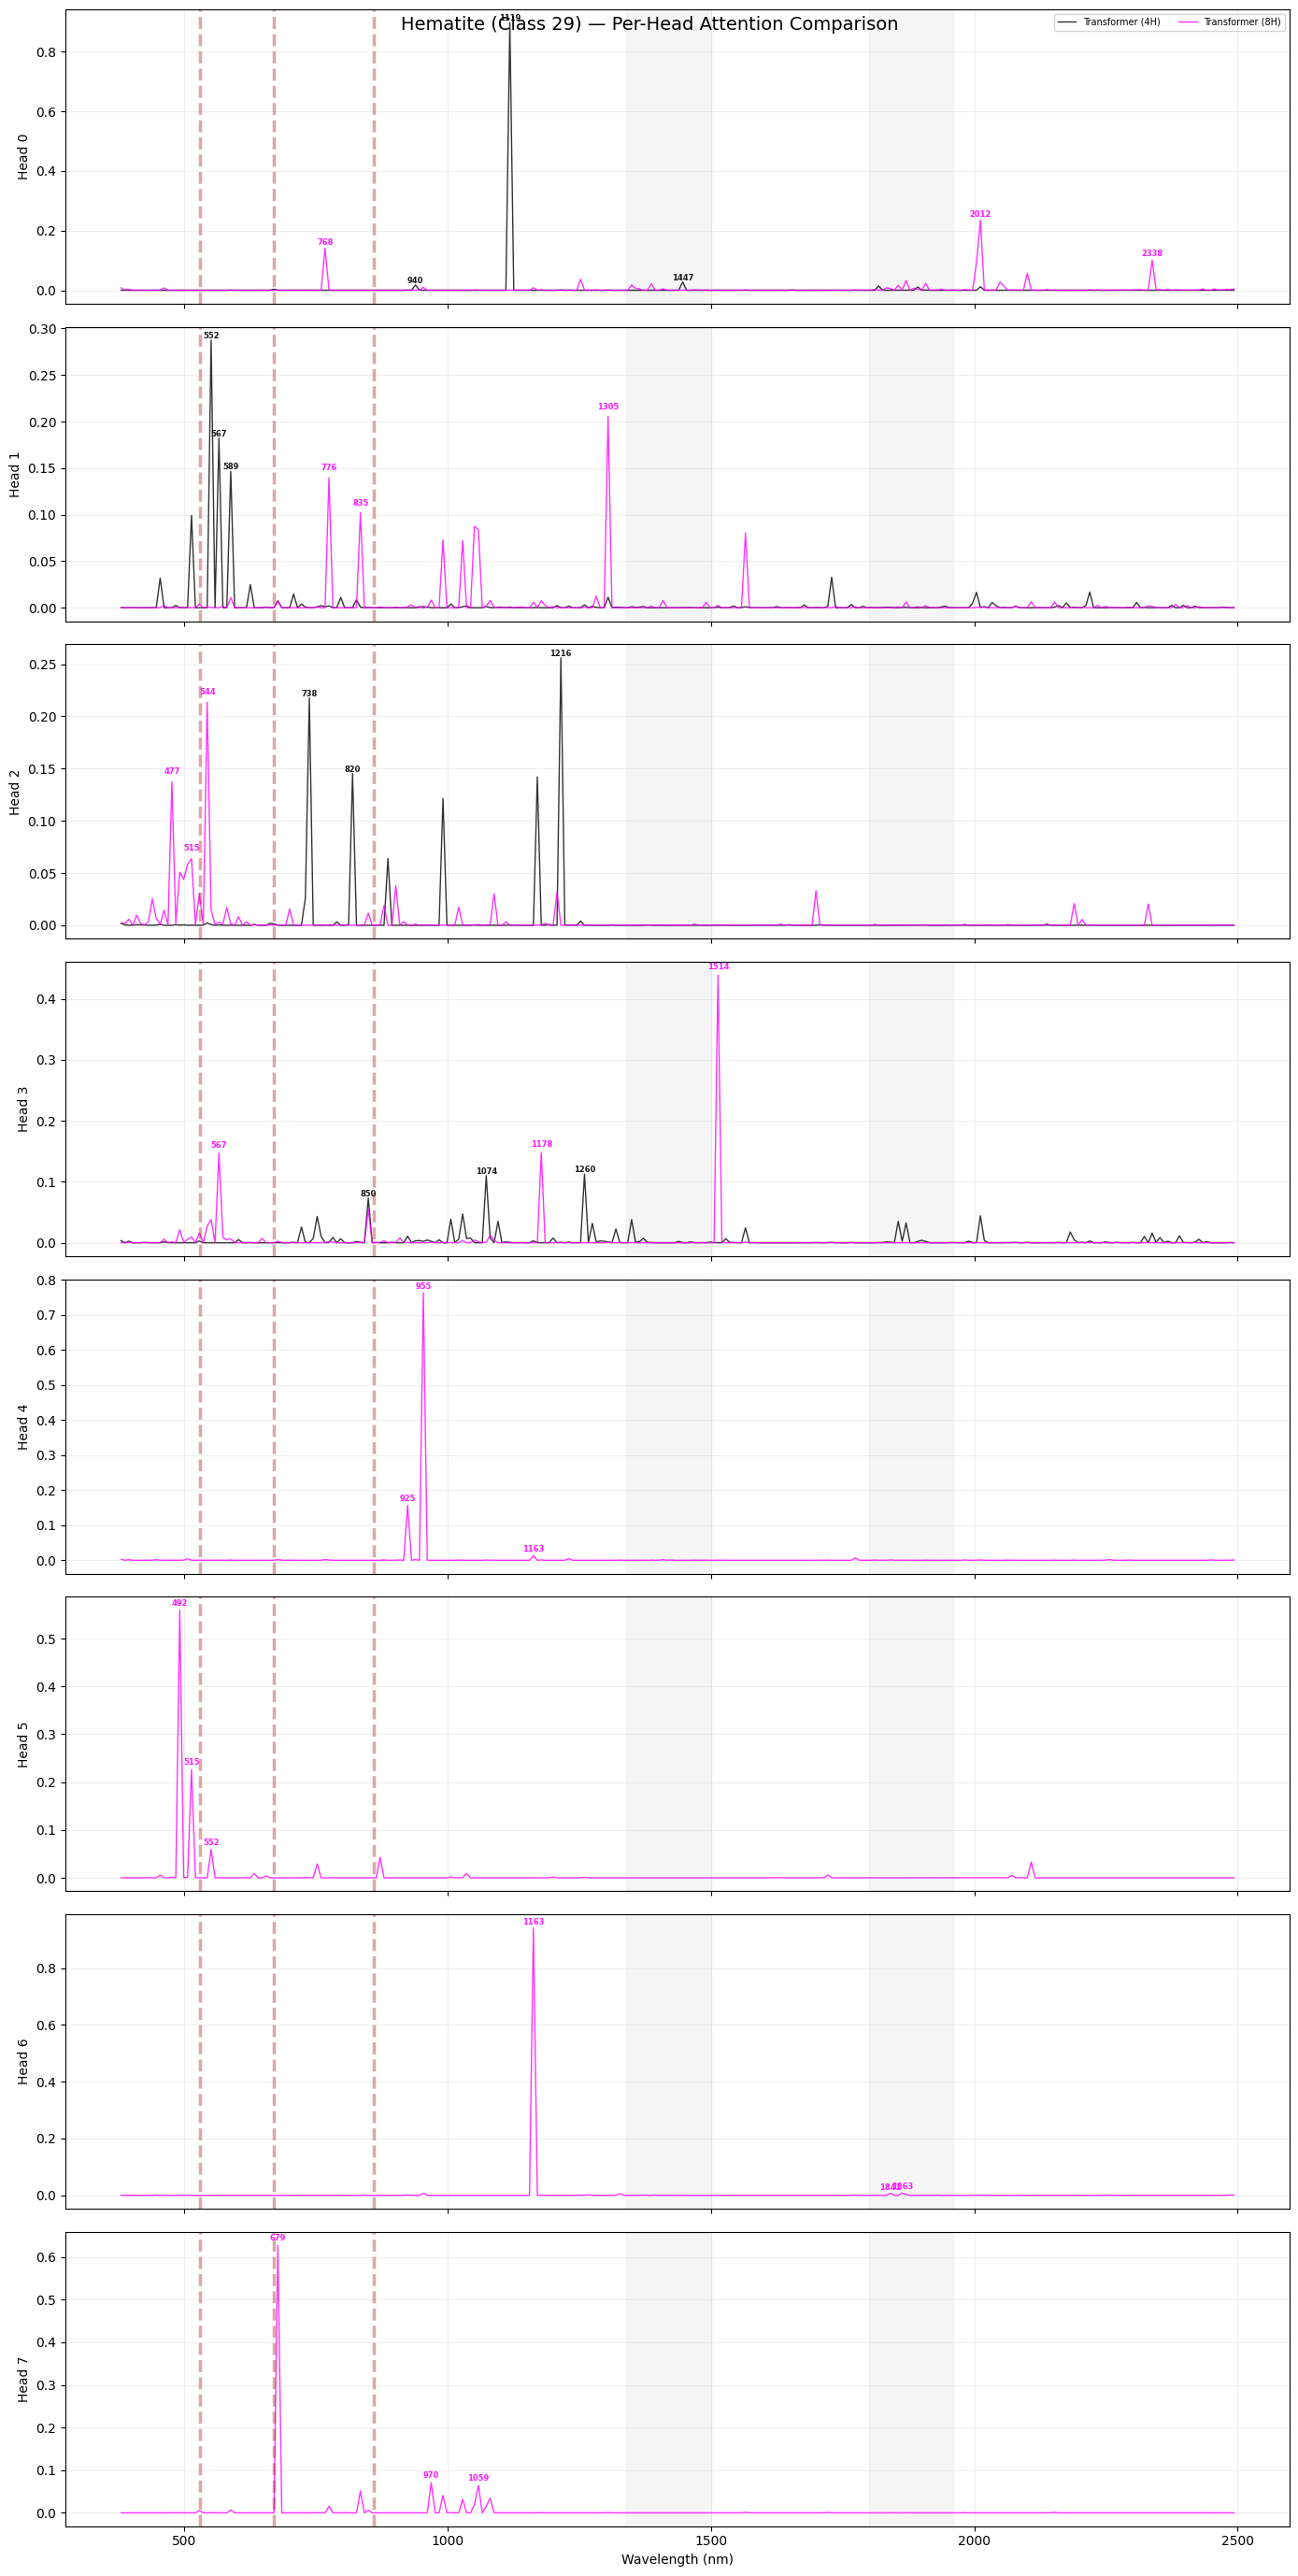

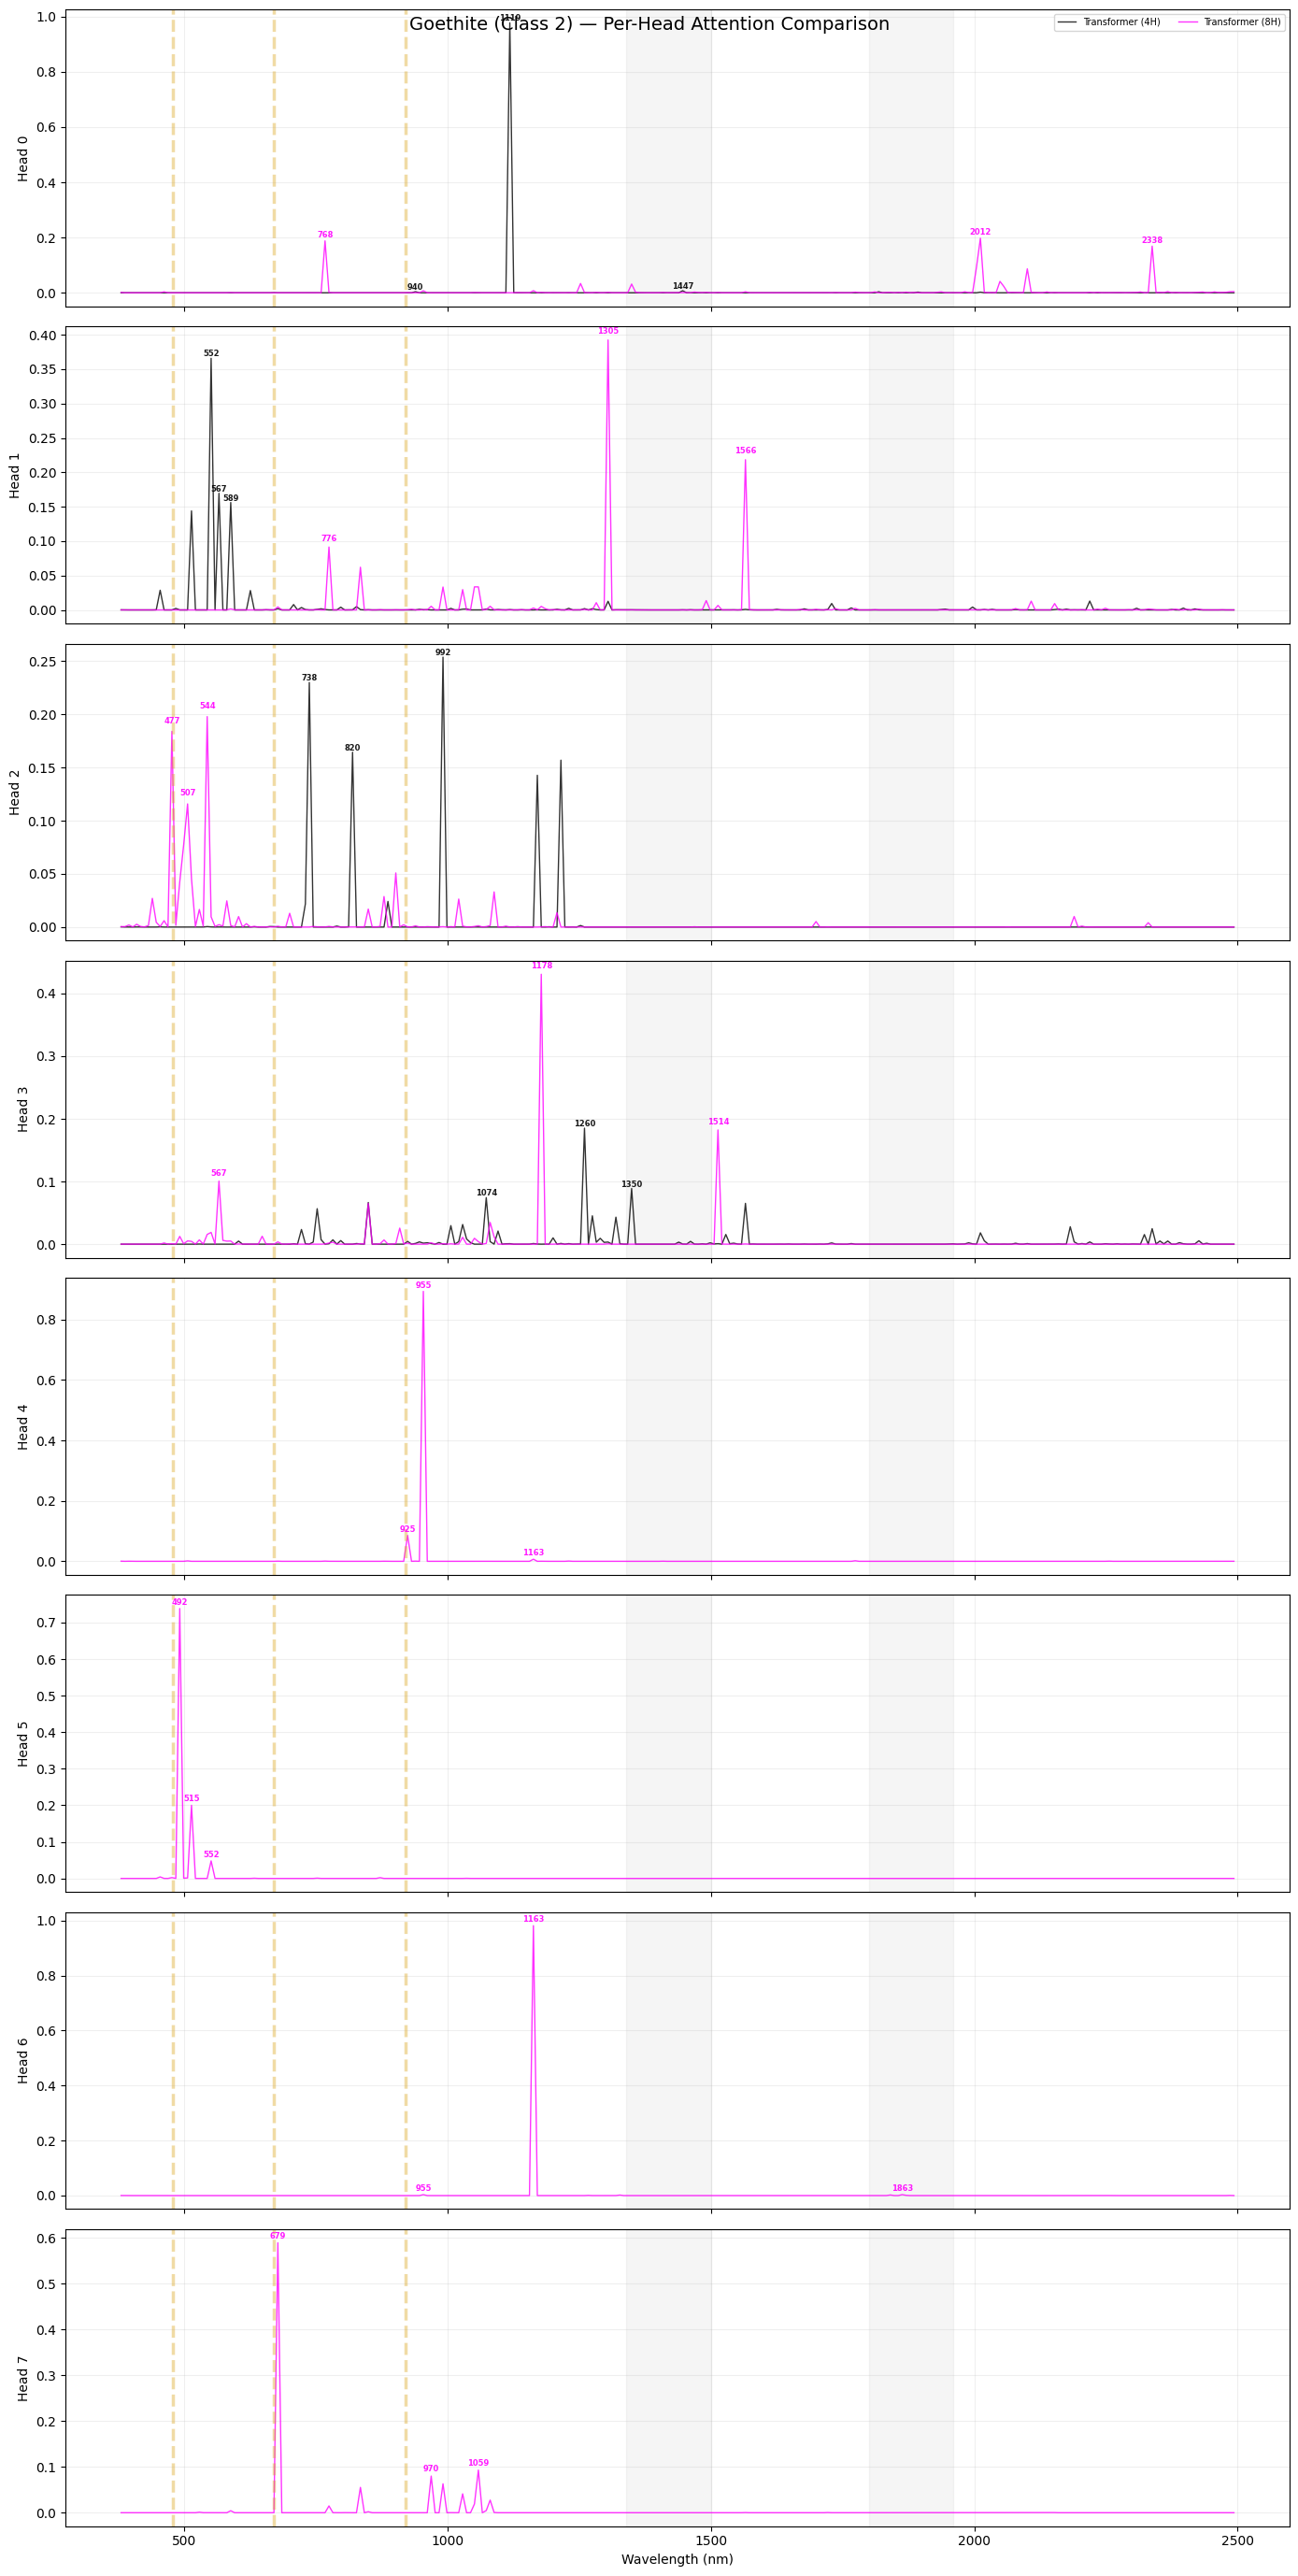

In [3]:
# ============================================================
# Compare per-head attention across 4 head and 8 head transformer architectures, for the hematite and goethite classes. Show top-3 peaks for each head and config, and overlay diagnostic bands.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- PATHS ---
base = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data"
wl_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data/emit_wavelength_centers_nm.npy"

configs = {
    "Transformer (4H)": {
        "dir": f"{base}/attn_outputs_Trans4_diff",
        "color": "black",
        "n_heads": 4,
    },
    "Transformer (8H)": {
        "dir": f"{base}/attn_outputs_Trans8_diff",
        "color": "magenta",
        "n_heads": 8,
    },
    #"PCA (8H)": {
    #    "dir": f"{base}/attn_outputs_PCA8_diffwt1_cont",
    #   "color": "firebrick",
    #    "n_heads": 8,
    #},
}

diagnostic_bands = {
    "Hematite":  {"bands": [530, 670, 860], "color": "firebrick"},
    "Goethite":  {"bands": [480, 670, 920], "color": "goldenrod"},
}

mineral_class_map = {
    "Hematite":  29,
    "Goethite":   2,
}

# --- LOAD ---
wl = np.load(wl_path)

# Load per-head attention for each config
attn_per_head = {}
for label, cfg in configs.items():
    attn_per_head[label] = {}
    for h in range(cfg["n_heads"]):
        try:
            attn_per_head[label][h] = np.loadtxt(
                f"{cfg['dir']}/band_attention_by_class_head{h}.csv", delimiter=","
            )
        except FileNotFoundError:
            pass

# --- PLOT: Compare heads 0-3 across configs, for each mineral ---
n_heads_to_show = 8  # show first 4 heads (all configs have at least 4)

for mineral_name, cls_idx in mineral_class_map.items():
    diag = diagnostic_bands.get(mineral_name, {})

    fig, axes = plt.subplots(n_heads_to_show, 1, figsize=(14, 3.5 * n_heads_to_show), sharex=True)
    fig.suptitle(f'{mineral_name} (Class {cls_idx}) — Per-Head Attention Comparison', fontsize=14)

    for h in range(n_heads_to_show):
        ax = axes[h]

        # Shade water vapor regions
        for lo, hi in [(1340, 1500), (1800, 1960)]:
            ax.axvspan(lo, hi, alpha=0.08, color='gray')

        # Plot each config's attention for this head
        for label, cfg in configs.items():
            if h in attn_per_head[label]:
                attn_h = attn_per_head[label][h][cls_idx]
                ax.plot(wl, attn_h, color=cfg["color"], linewidth=1.0, alpha=0.8, label=label)

        # Overlay diagnostic bands
        for band_nm in diag.get("bands", []):
            ax.axvline(band_nm, color=diag["color"], linestyle='--', linewidth=2.5, alpha=0.4)

        # Annotate top-3 peaks for each config
        y_offset_step = 0.006  # vertical offset to avoid overlapping labels
        for i_cfg, (label, cfg) in enumerate(configs.items()):
            if h in attn_per_head[label]:
                attn_h_cfg = attn_per_head[label][h][cls_idx]
                top3 = np.argsort(attn_h_cfg)[-3:]
                for idx in top3:
                    ax.annotate(f'{wl[idx]:.0f}',
                                xy=(wl[idx], attn_h_cfg[idx] + y_offset_step * i_cfg),
                                fontsize=6, ha='center', va='bottom',
                                color=cfg["color"], alpha=0.9, fontweight='bold')

        ax.set_ylabel(f'Head {h}')
        ax.grid(True, alpha=0.2)
        if h == 0:
            ax.legend(loc='upper right', fontsize=7, ncol=3)

    axes[-1].set_xlabel('Wavelength (nm)')
    plt.tight_layout()
    plt.savefig(f"{base}/perhead_comparison_{mineral_name}.png", dpi=150)
    plt.show()


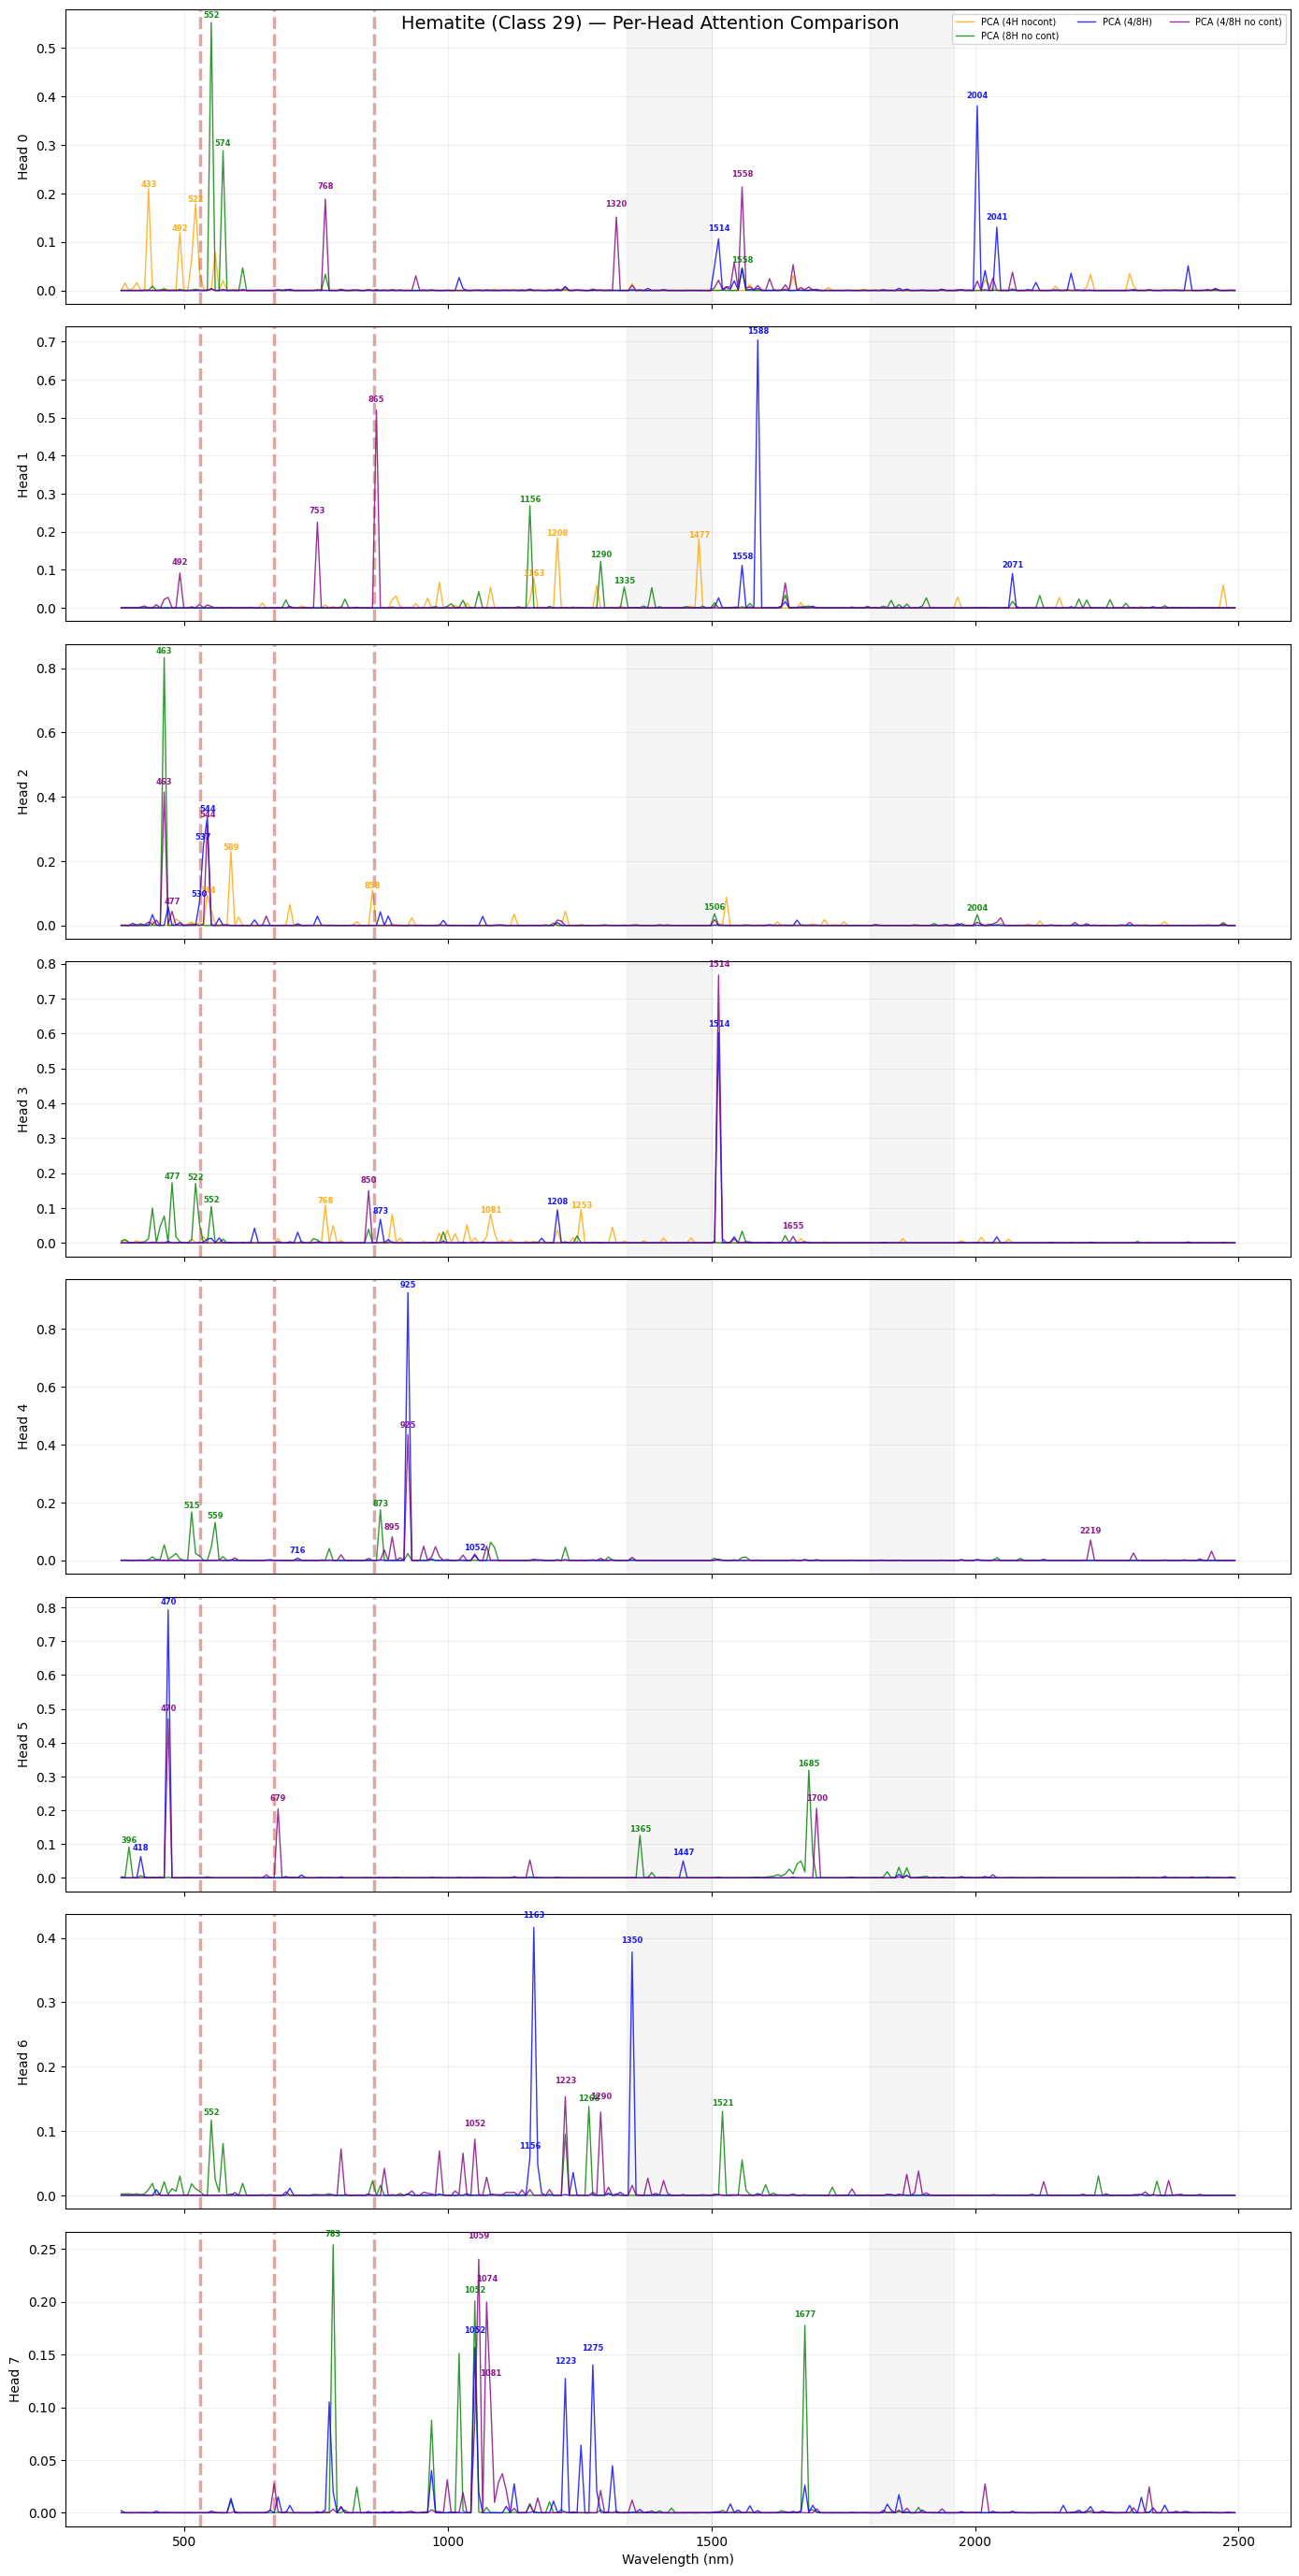

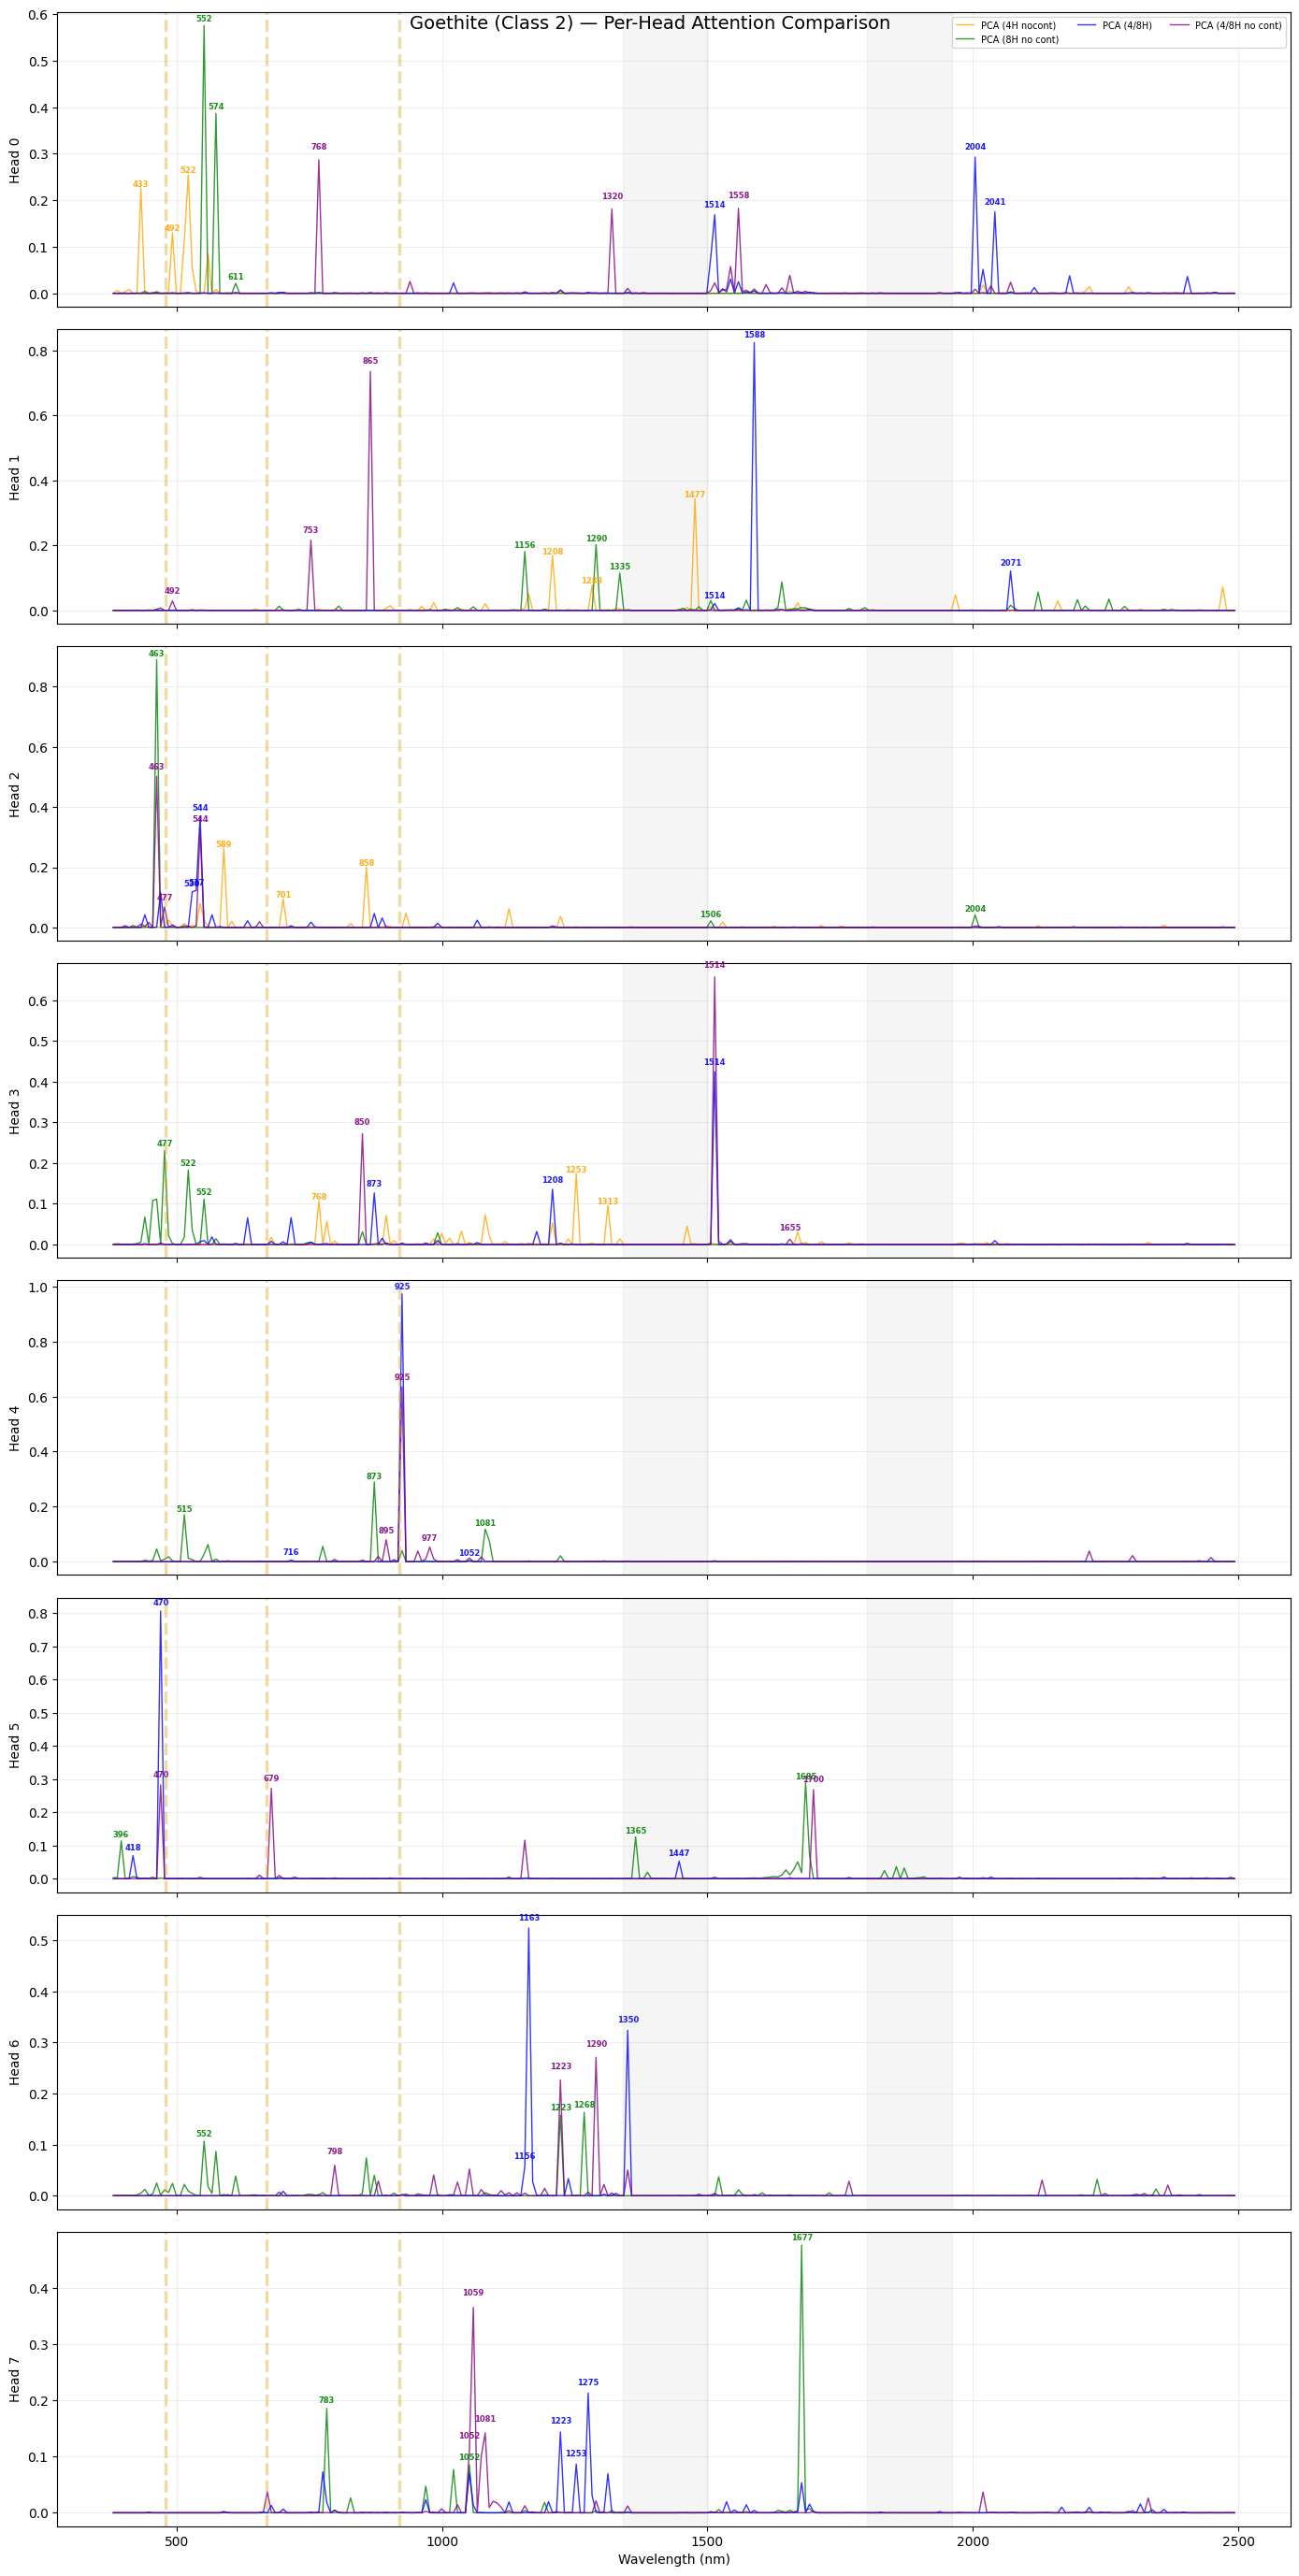

In [17]:
# ============================================================
# Compare per-head attention across PCA architectures, for the hematite and goethite classes. Show top-3 peaks for each head and config, and overlay diagnostic bands.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- PATHS ---
base = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data"
wl_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data/emit_wavelength_centers_nm.npy"

configs = {
        #"PCA (4H)": {
        #"dir": f"{base}/attn_outputs_PCA4_diffwt1_cont",
        #"color": "red",
        #"n_heads": 4,
    #},
        "PCA (4H nocont)": {
        "dir": f"{base}/attn_outputs_PCA4_diffwt1_nocont",
        "color": "orange",
        "n_heads": 8,
    },
        "PCA (8H no cont)": {
        "dir": f"{base}/attn_outputs_PCA8_diffwt1_nocont",
        "color": "green",
        "n_heads": 8,
    },
        "PCA (4/8H)": {
        "dir": f"{base}/attn_outputs_PCA4_8_diffwt1_cont",
        "color": "blue",
        "n_heads": 8,
    },
        "PCA (4/8H no cont)": {
        "dir": f"{base}/attn_outputs_PCA4_8_diffwt1_nocont",
        "color": "purple",
        "n_heads": 8,
    },

    #"Lusi (4H)": {
    #    "dir": f"{base}/attn_outputs_Lusi4_diffwt1",
    #    "color": "green",
    #    "n_heads": 4,
    #},
}

diagnostic_bands = {
    "Hematite":  {"bands": [530, 670, 860], "color": "firebrick"},
    "Goethite":  {"bands": [480, 670, 920], "color": "goldenrod"},
}

mineral_class_map = {
    "Hematite":  29,
    "Goethite":   2,
}

# --- LOAD ---
wl = np.load(wl_path)

# Load per-head attention for each config
attn_per_head = {}
for label, cfg in configs.items():
    attn_per_head[label] = {}
    for h in range(cfg["n_heads"]):
        try:
            attn_per_head[label][h] = np.loadtxt(
                f"{cfg['dir']}/band_attention_by_class_head{h}.csv", delimiter=","
            )
        except FileNotFoundError:
            pass

# --- PLOT: Compare heads 0-3 across configs, for each mineral ---
n_heads_to_show = 8  # show first 4 heads (all configs have at least 4)

for mineral_name, cls_idx in mineral_class_map.items():
    diag = diagnostic_bands.get(mineral_name, {})

    fig, axes = plt.subplots(n_heads_to_show, 1, figsize=(14, 3.5 * n_heads_to_show), sharex=True)
    fig.suptitle(f'{mineral_name} (Class {cls_idx}) — Per-Head Attention Comparison', fontsize=14)

    for h in range(n_heads_to_show):
        ax = axes[h]

        # Shade water vapor regions
        for lo, hi in [(1340, 1500), (1800, 1960)]:
            ax.axvspan(lo, hi, alpha=0.08, color='gray')

        # Plot each config's attention for this head
        for label, cfg in configs.items():
            if h in attn_per_head[label]:
                attn_h = attn_per_head[label][h][cls_idx]
                ax.plot(wl, attn_h, color=cfg["color"], linewidth=1.0, alpha=0.8, label=label)

        # Overlay diagnostic bands
        for band_nm in diag.get("bands", []):
            ax.axvline(band_nm, color=diag["color"], linestyle='--', linewidth=2.5, alpha=0.4)

        # Annotate top-3 peaks for each config
        y_offset_step = 0.006  # vertical offset to avoid overlapping labels
        for i_cfg, (label, cfg) in enumerate(configs.items()):
            if h in attn_per_head[label]:
                attn_h_cfg = attn_per_head[label][h][cls_idx]
                top3 = np.argsort(attn_h_cfg)[-3:]
                for idx in top3:
                    ax.annotate(f'{wl[idx]:.0f}',
                                xy=(wl[idx], attn_h_cfg[idx] + y_offset_step * i_cfg),
                                fontsize=6, ha='center', va='bottom',
                                color=cfg["color"], alpha=0.9, fontweight='bold')

        ax.set_ylabel(f'Head {h}')
        ax.grid(True, alpha=0.2)
        if h == 0:
            ax.legend(loc='upper right', fontsize=7, ncol=3)

    axes[-1].set_xlabel('Wavelength (nm)')
    plt.tight_layout()
    plt.savefig(f"{base}/perhead_comparison_{mineral_name}.png", dpi=150)
    plt.show()


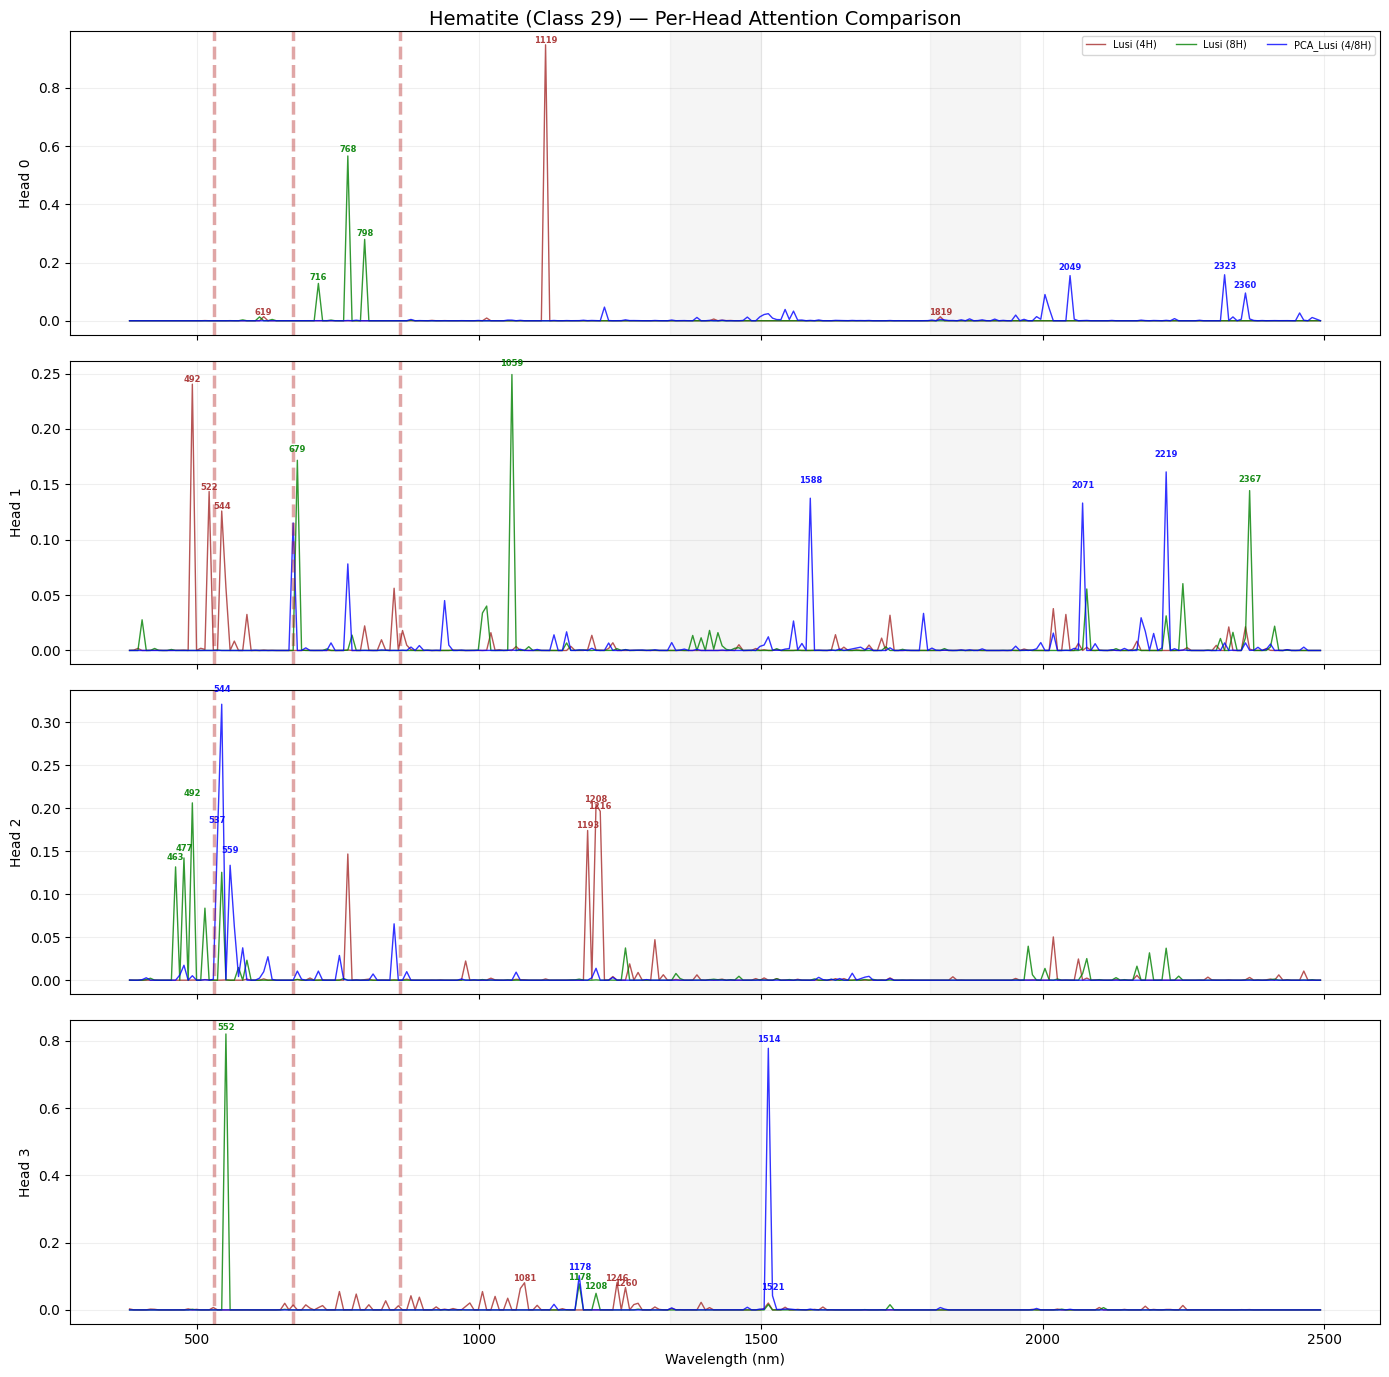

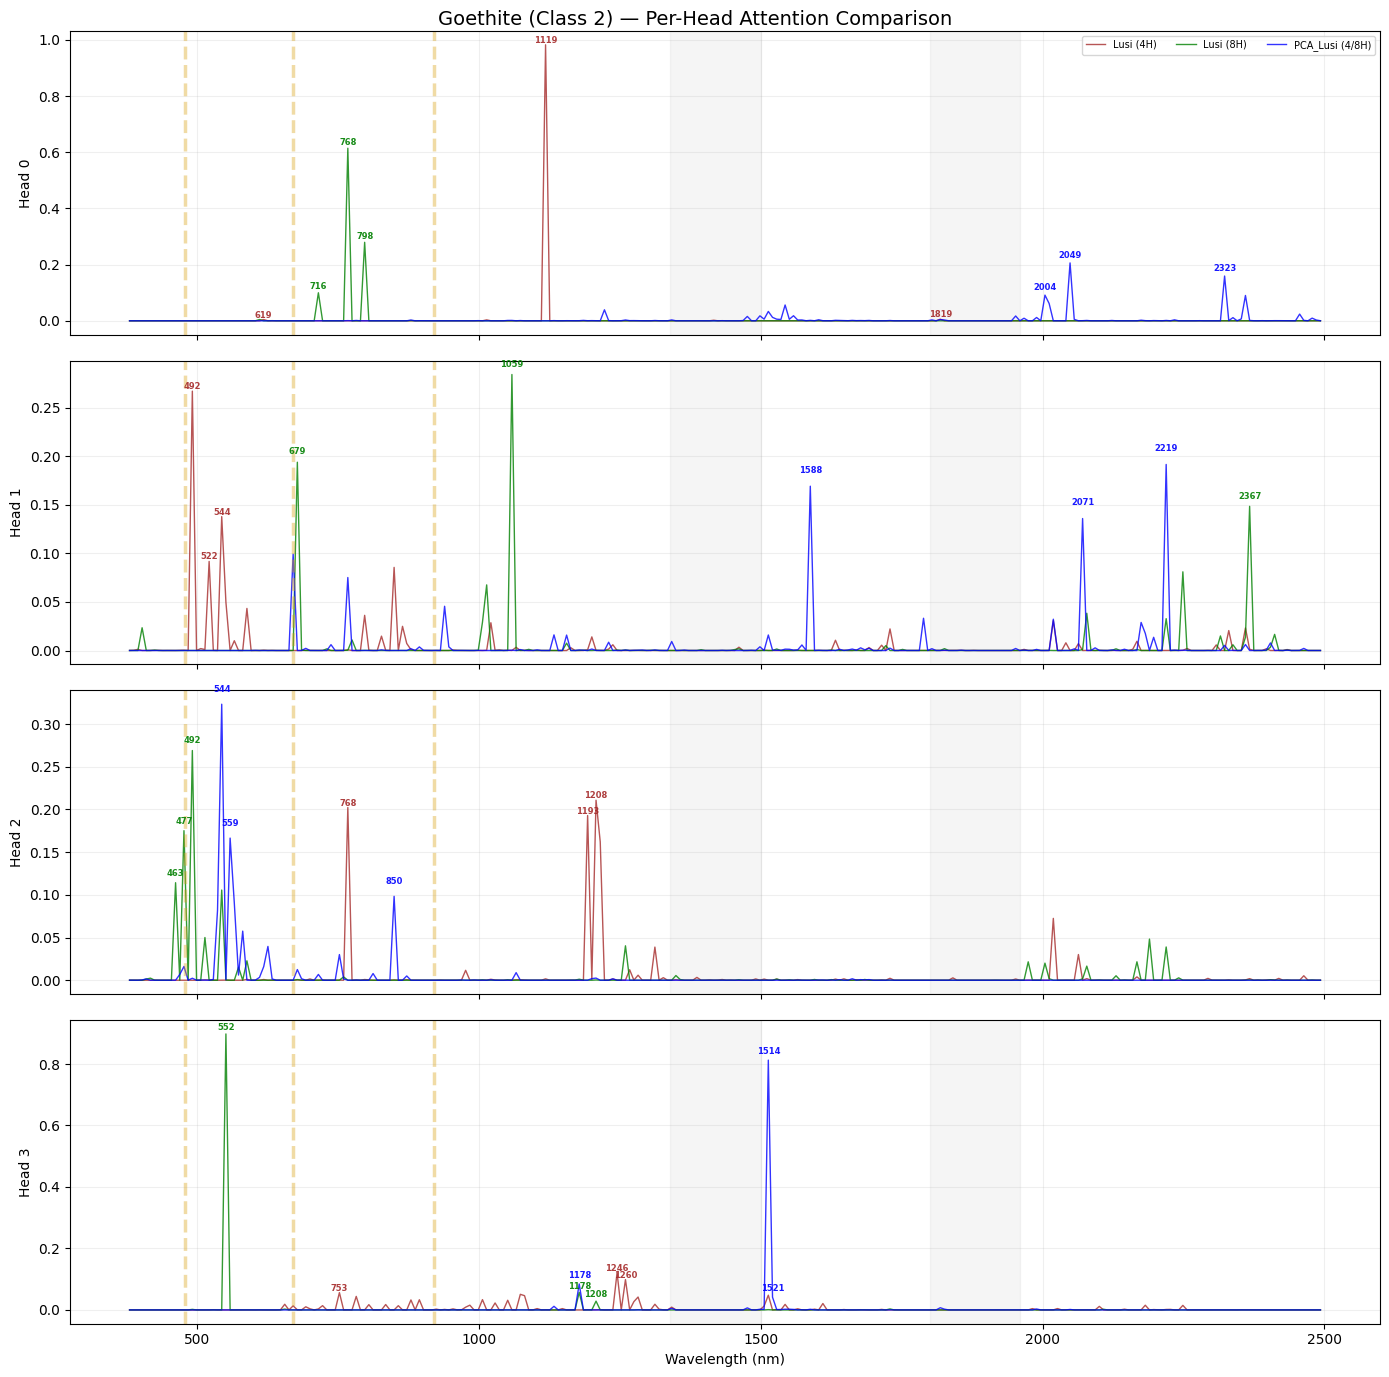

In [7]:
# ============================================================
# Compare per-head attention across LUSI architectures, for the hematite and goethite classes. Show top-3 peaks for each head and config, and overlay diagnostic bands.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- PATHS ---
base = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data"
wl_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data/emit_wavelength_centers_nm.npy"

configs = {
        "Lusi (4H)": {
        "dir": f"{base}/attn_outputs_Lusi4_diffwt1",
        "color": "brown",
        "n_heads": 4,
    },
        "Lusi (8H)": {
        "dir": f"{base}/attn_outputs_Lusi8_diffwt1",
        "color": "green",
        "n_heads": 8,
    },
        "PCA_Lusi (4/8H)": {
        "dir": f"{base}/attn_outputs_PCALUSI4_8_diffcont_wts1",
        "color": "blue",
        "n_heads": 8,
    },
}

diagnostic_bands = {
    "Hematite":  {"bands": [530, 670, 860], "color": "firebrick"},
    "Goethite":  {"bands": [480, 670, 920], "color": "goldenrod"},
}

mineral_class_map = {
    "Hematite":  29,
    "Goethite":   2,
}

# --- LOAD ---
wl = np.load(wl_path)

# Load per-head attention for each config
attn_per_head = {}
for label, cfg in configs.items():
    attn_per_head[label] = {}
    for h in range(cfg["n_heads"]):
        try:
            attn_per_head[label][h] = np.loadtxt(
                f"{cfg['dir']}/band_attention_by_class_head{h}.csv", delimiter=","
            )
        except FileNotFoundError:
            pass

# --- PLOT: Compare heads 0-3 across configs, for each mineral ---
n_heads_to_show = 4  # show first 4 heads (all configs have at least 4)

for mineral_name, cls_idx in mineral_class_map.items():
    diag = diagnostic_bands.get(mineral_name, {})

    fig, axes = plt.subplots(n_heads_to_show, 1, figsize=(14, 3.5 * n_heads_to_show), sharex=True)
    fig.suptitle(f'{mineral_name} (Class {cls_idx}) — Per-Head Attention Comparison', fontsize=14)

    for h in range(n_heads_to_show):
        ax = axes[h]

        # Shade water vapor regions
        for lo, hi in [(1340, 1500), (1800, 1960)]:
            ax.axvspan(lo, hi, alpha=0.08, color='gray')

        # Plot each config's attention for this head
        for label, cfg in configs.items():
            if h in attn_per_head[label]:
                attn_h = attn_per_head[label][h][cls_idx]
                ax.plot(wl, attn_h, color=cfg["color"], linewidth=1.0, alpha=0.8, label=label)

        # Overlay diagnostic bands
        for band_nm in diag.get("bands", []):
            ax.axvline(band_nm, color=diag["color"], linestyle='--', linewidth=2.5, alpha=0.4)

        # Annotate top-3 peaks for each config
        y_offset_step = 0.006  # vertical offset to avoid overlapping labels
        for i_cfg, (label, cfg) in enumerate(configs.items()):
            if h in attn_per_head[label]:
                attn_h_cfg = attn_per_head[label][h][cls_idx]
                top3 = np.argsort(attn_h_cfg)[-3:]
                for idx in top3:
                    ax.annotate(f'{wl[idx]:.0f}',
                                xy=(wl[idx], attn_h_cfg[idx] + y_offset_step * i_cfg),
                                fontsize=6, ha='center', va='bottom',
                                color=cfg["color"], alpha=0.9, fontweight='bold')

        ax.set_ylabel(f'Head {h}')
        ax.grid(True, alpha=0.2)
        if h == 0:
            ax.legend(loc='upper right', fontsize=7, ncol=3)

    axes[-1].set_xlabel('Wavelength (nm)')
    plt.tight_layout()
    plt.savefig(f"{base}/perhead_comparison_{mineral_name}.png", dpi=150)
    plt.show()


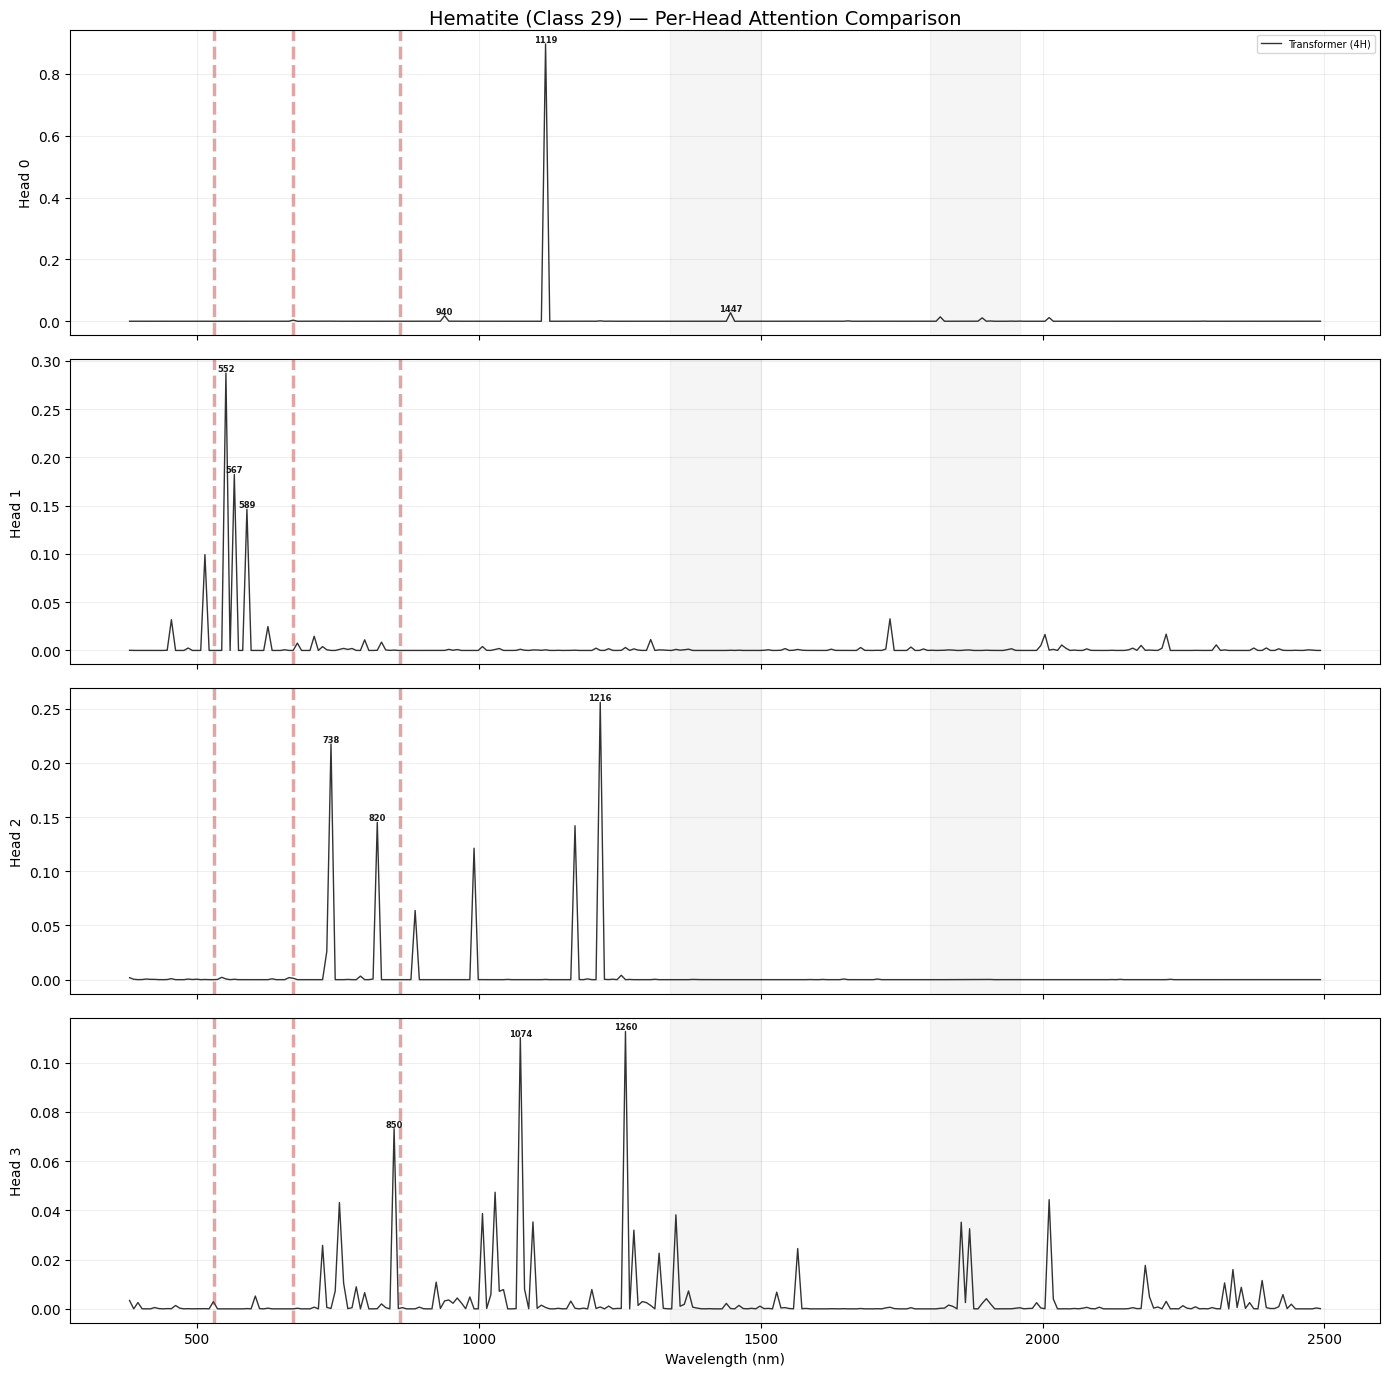

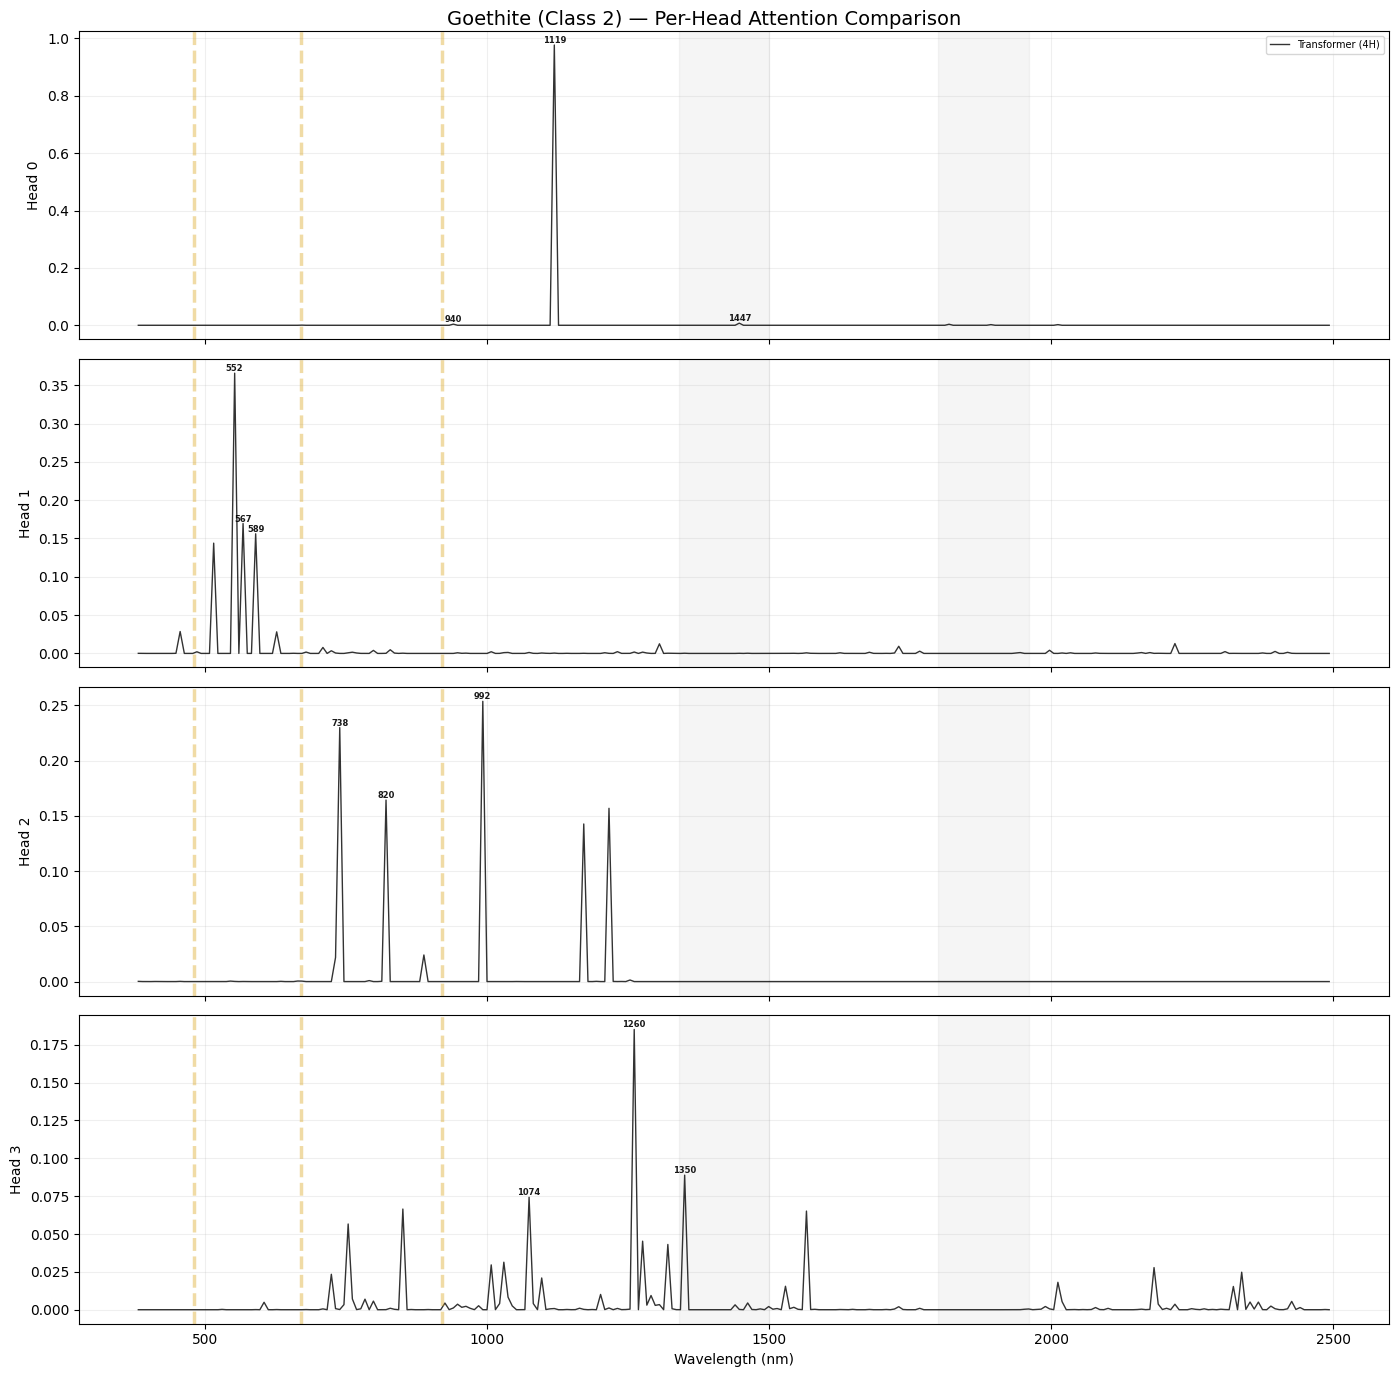

In [9]:
# ============================================================
# Compare per-head attention: 4H Transformer only
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- PATHS ---
base = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data"
wl_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data/emit_wavelength_centers_nm.npy"

configs = {
    "Transformer (4H)": {
        "dir": f"{base}/attn_outputs_Trans4_diff",
        "color": "black",
        "n_heads": 4,
    },
    #"Transformer (8H)": {
    #    "dir": f"{base}/attn_outputs_Trans8_diff",
    #    "color": "magenta",
    #    "n_heads": 8,
    #},
    #"PCA (8H)": {
    #    "dir": f"{base}/attn_outputs_PCA8_diffwt1_cont",
    #   "color": "firebrick",
    #    "n_heads": 8,
    #},
}

diagnostic_bands = {
    "Hematite":  {"bands": [530, 670, 860], "color": "firebrick"},
    "Goethite":  {"bands": [480, 670, 920], "color": "goldenrod"},
}

mineral_class_map = {
    "Hematite":  29,
    "Goethite":   2,
}

# --- LOAD ---
wl = np.load(wl_path)

# Load per-head attention for each config
attn_per_head = {}
for label, cfg in configs.items():
    attn_per_head[label] = {}
    for h in range(cfg["n_heads"]):
        try:
            attn_per_head[label][h] = np.loadtxt(
                f"{cfg['dir']}/band_attention_by_class_head{h}.csv", delimiter=","
            )
        except FileNotFoundError:
            pass

# --- PLOT: Compare heads 0-3 across configs, for each mineral ---
n_heads_to_show = 4  # show first 4 heads (all configs have at least 4)

for mineral_name, cls_idx in mineral_class_map.items():
    diag = diagnostic_bands.get(mineral_name, {})

    fig, axes = plt.subplots(n_heads_to_show, 1, figsize=(14, 3.5 * n_heads_to_show), sharex=True)
    fig.suptitle(f'{mineral_name} (Class {cls_idx}) — Per-Head Attention Comparison', fontsize=14)

    for h in range(n_heads_to_show):
        ax = axes[h]

        # Shade water vapor regions
        for lo, hi in [(1340, 1500), (1800, 1960)]:
            ax.axvspan(lo, hi, alpha=0.08, color='gray')

        # Plot each config's attention for this head
        for label, cfg in configs.items():
            if h in attn_per_head[label]:
                attn_h = attn_per_head[label][h][cls_idx]
                ax.plot(wl, attn_h, color=cfg["color"], linewidth=1.0, alpha=0.8, label=label)

        # Overlay diagnostic bands
        for band_nm in diag.get("bands", []):
            ax.axvline(band_nm, color=diag["color"], linestyle='--', linewidth=2.5, alpha=0.4)

        # Annotate top-3 peaks for each config
        y_offset_step = 0.006  # vertical offset to avoid overlapping labels
        for i_cfg, (label, cfg) in enumerate(configs.items()):
            if h in attn_per_head[label]:
                attn_h_cfg = attn_per_head[label][h][cls_idx]
                top3 = np.argsort(attn_h_cfg)[-3:]
                for idx in top3:
                    ax.annotate(f'{wl[idx]:.0f}',
                                xy=(wl[idx], attn_h_cfg[idx] + y_offset_step * i_cfg),
                                fontsize=6, ha='center', va='bottom',
                                color=cfg["color"], alpha=0.9, fontweight='bold')

        ax.set_ylabel(f'Head {h}')
        ax.grid(True, alpha=0.2)
        if h == 0:
            ax.legend(loc='upper right', fontsize=7, ncol=3)

    axes[-1].set_xlabel('Wavelength (nm)')
    plt.tight_layout()
    plt.savefig(f"{base}/perhead_comparison_{mineral_name}.png", dpi=150)
    plt.show()


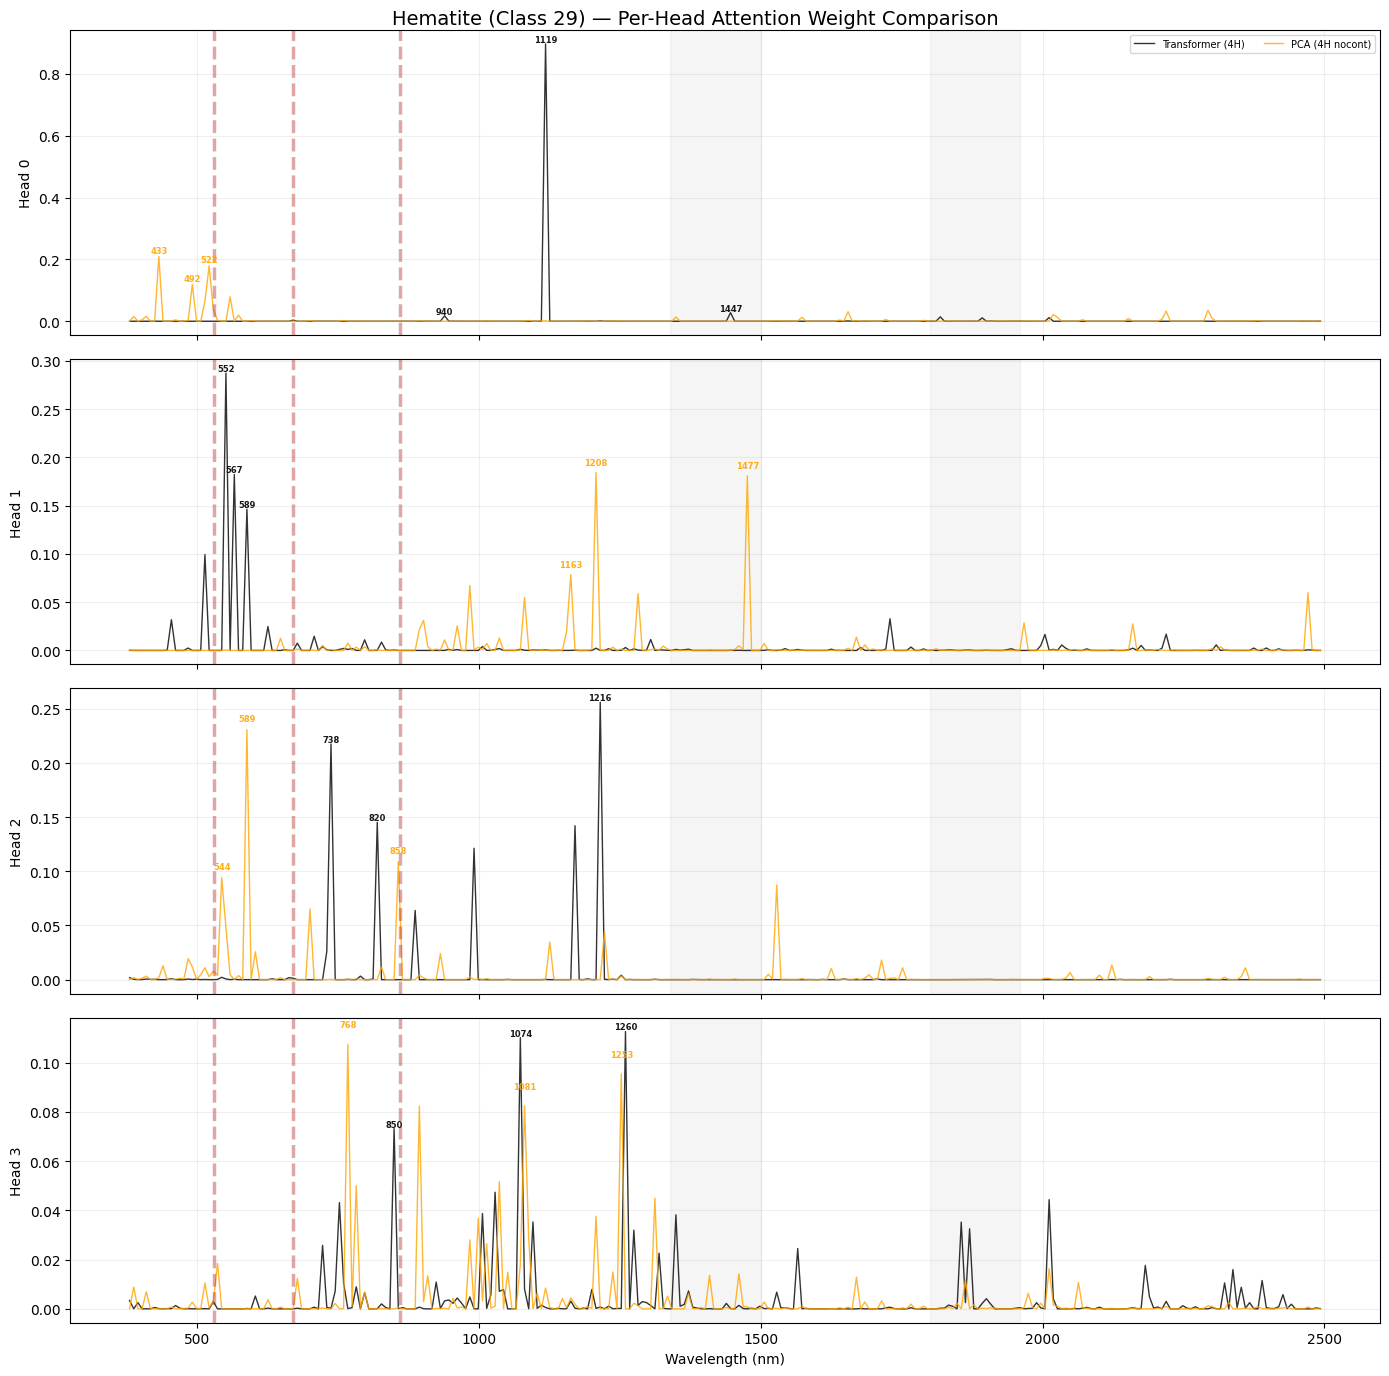

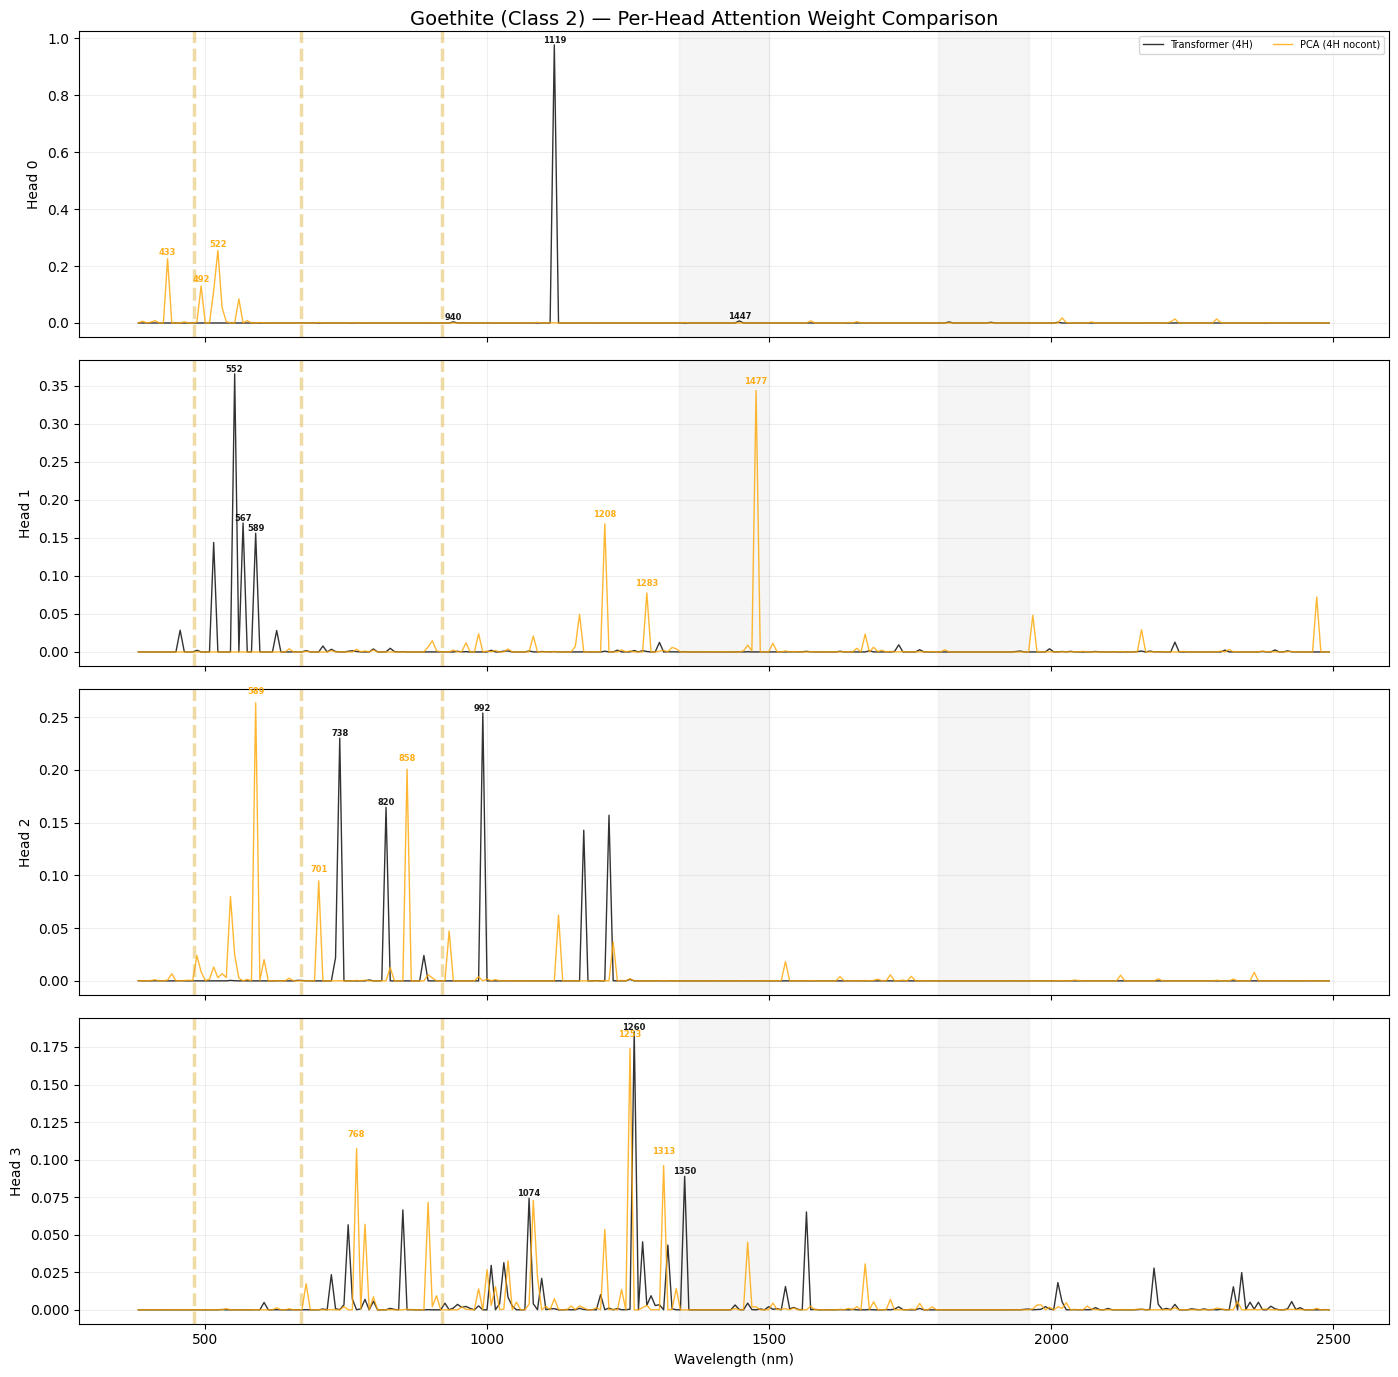

In [19]:
# ============================================================
# Compare per-head attention: 4H Transformer +PCA selection
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- PATHS ---
base = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data"
wl_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data/emit_wavelength_centers_nm.npy"

configs = {
    "Transformer (4H)": {
        "dir": f"{base}/attn_outputs_Trans4_diff",
        "color": "black",
        "n_heads": 4,
    },
    #"Transformer (8H)": {
    #    "dir": f"{base}/attn_outputs_Trans8_diff",
    #    "color": "magenta",
    #    "n_heads": 8,
    #},
    "PCA (4H nocont)": {
        "dir": f"{base}/attn_outputs_PCA4_diffwt1_nocont",
       "color": "orange",
        "n_heads": 4,
    },
}

diagnostic_bands = {
    "Hematite":  {"bands": [530, 670, 860], "color": "firebrick"},
    "Goethite":  {"bands": [480, 670, 920], "color": "goldenrod"},
}

mineral_class_map = {
    "Hematite":  29,
    "Goethite":   2,
}

# --- LOAD ---
wl = np.load(wl_path)

# Load per-head attention for each config
attn_per_head = {}
for label, cfg in configs.items():
    attn_per_head[label] = {}
    for h in range(cfg["n_heads"]):
        try:
            attn_per_head[label][h] = np.loadtxt(
                f"{cfg['dir']}/band_attention_by_class_head{h}.csv", delimiter=","
            )
        except FileNotFoundError:
            pass

# --- PLOT: Compare heads 0-3 across configs, for each mineral ---
n_heads_to_show = 4  # show first 4 heads (all configs have at least 4)

for mineral_name, cls_idx in mineral_class_map.items():
    diag = diagnostic_bands.get(mineral_name, {})

    fig, axes = plt.subplots(n_heads_to_show, 1, figsize=(14, 3.5 * n_heads_to_show), sharex=True)
    fig.suptitle(f'{mineral_name} (Class {cls_idx}) — Per-Head Attention Weight Comparison', fontsize=14)

    for h in range(n_heads_to_show):
        ax = axes[h]

        # Shade water vapor regions
        for lo, hi in [(1340, 1500), (1800, 1960)]:
            ax.axvspan(lo, hi, alpha=0.08, color='gray')

        # Plot each config's attention for this head
        for label, cfg in configs.items():
            if h in attn_per_head[label]:
                attn_h = attn_per_head[label][h][cls_idx]
                ax.plot(wl, attn_h, color=cfg["color"], linewidth=1.0, alpha=0.8, label=label)

        # Overlay diagnostic bands
        for band_nm in diag.get("bands", []):
            ax.axvline(band_nm, color=diag["color"], linestyle='--', linewidth=2.5, alpha=0.4)

        # Annotate top-3 peaks for each config
        y_offset_step = 0.006  # vertical offset to avoid overlapping labels
        for i_cfg, (label, cfg) in enumerate(configs.items()):
            if h in attn_per_head[label]:
                attn_h_cfg = attn_per_head[label][h][cls_idx]
                top3 = np.argsort(attn_h_cfg)[-3:]
                for idx in top3:
                    ax.annotate(f'{wl[idx]:.0f}',
                                xy=(wl[idx], attn_h_cfg[idx] + y_offset_step * i_cfg),
                                fontsize=6, ha='center', va='bottom',
                                color=cfg["color"], alpha=0.9, fontweight='bold')

        ax.set_ylabel(f'Head {h}')
        ax.grid(True, alpha=0.2)
        if h == 0:
            ax.legend(loc='upper right', fontsize=7, ncol=3)

    axes[-1].set_xlabel('Wavelength (nm)')
    plt.tight_layout()
    plt.savefig(f"{base}/perhead_comparison_{mineral_name}.png", dpi=150)
    plt.show()


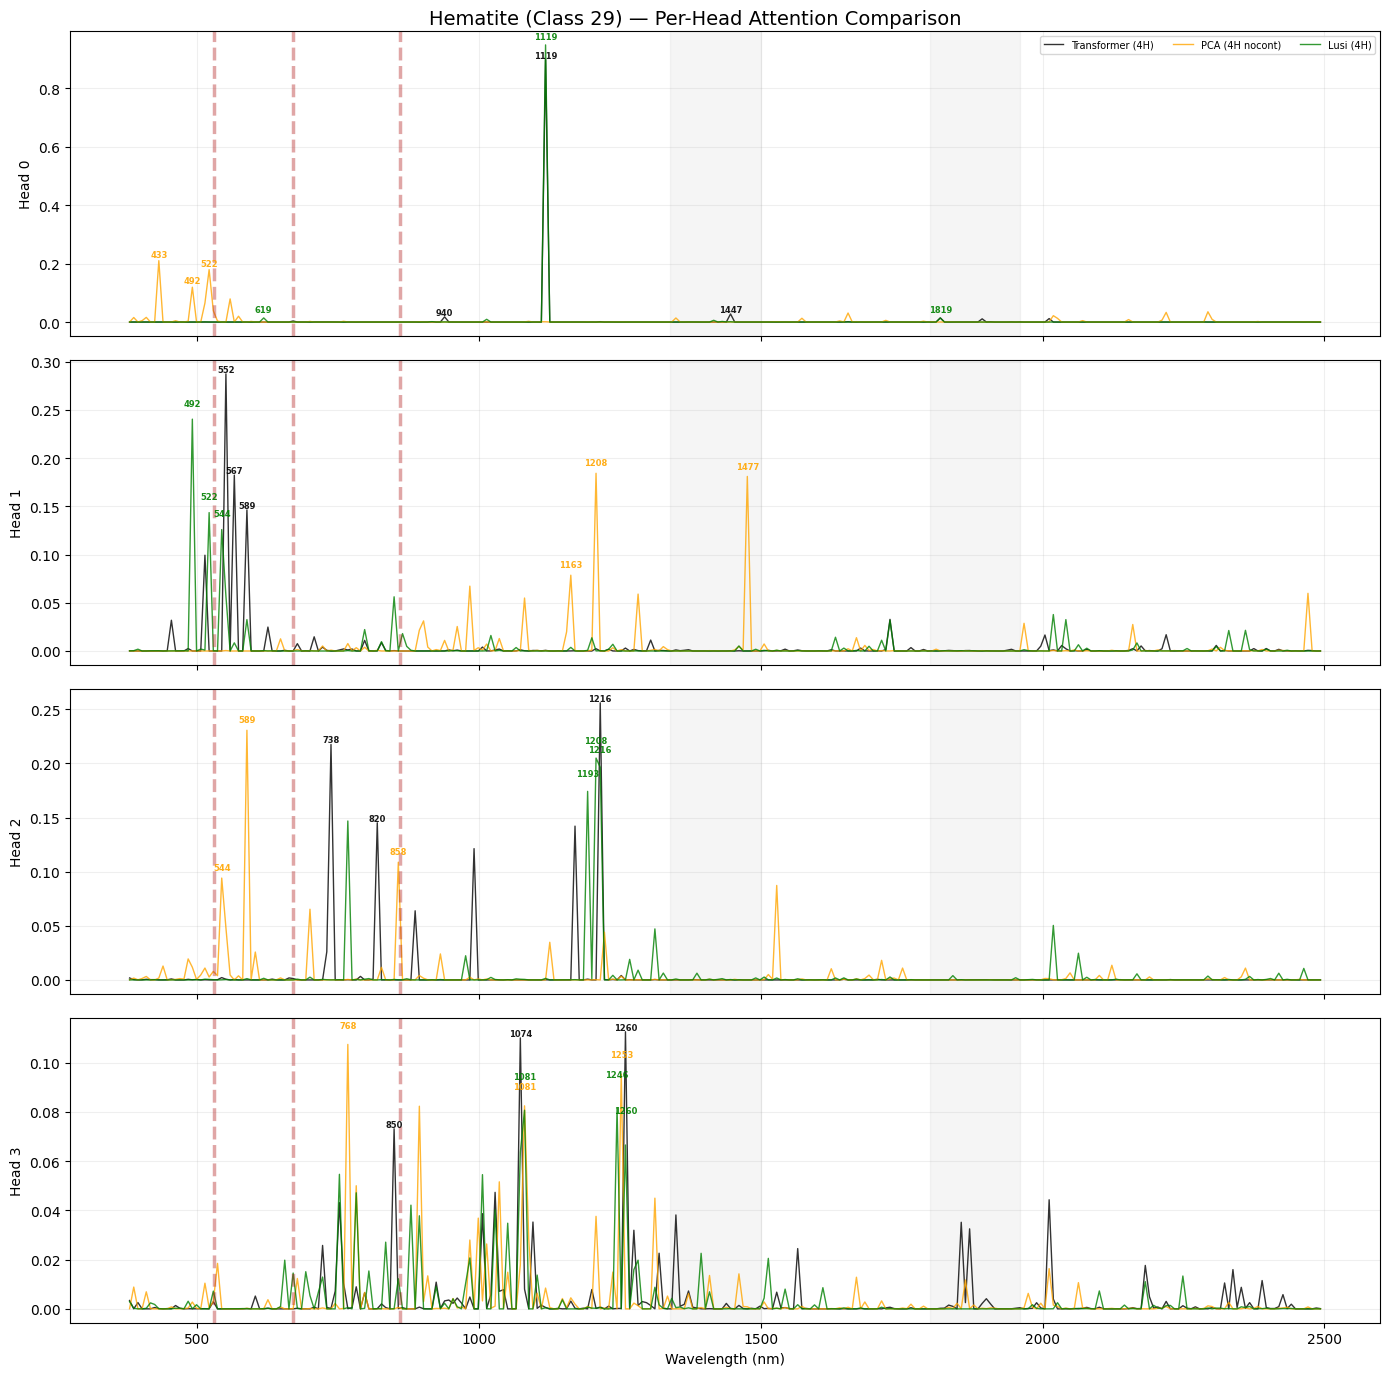

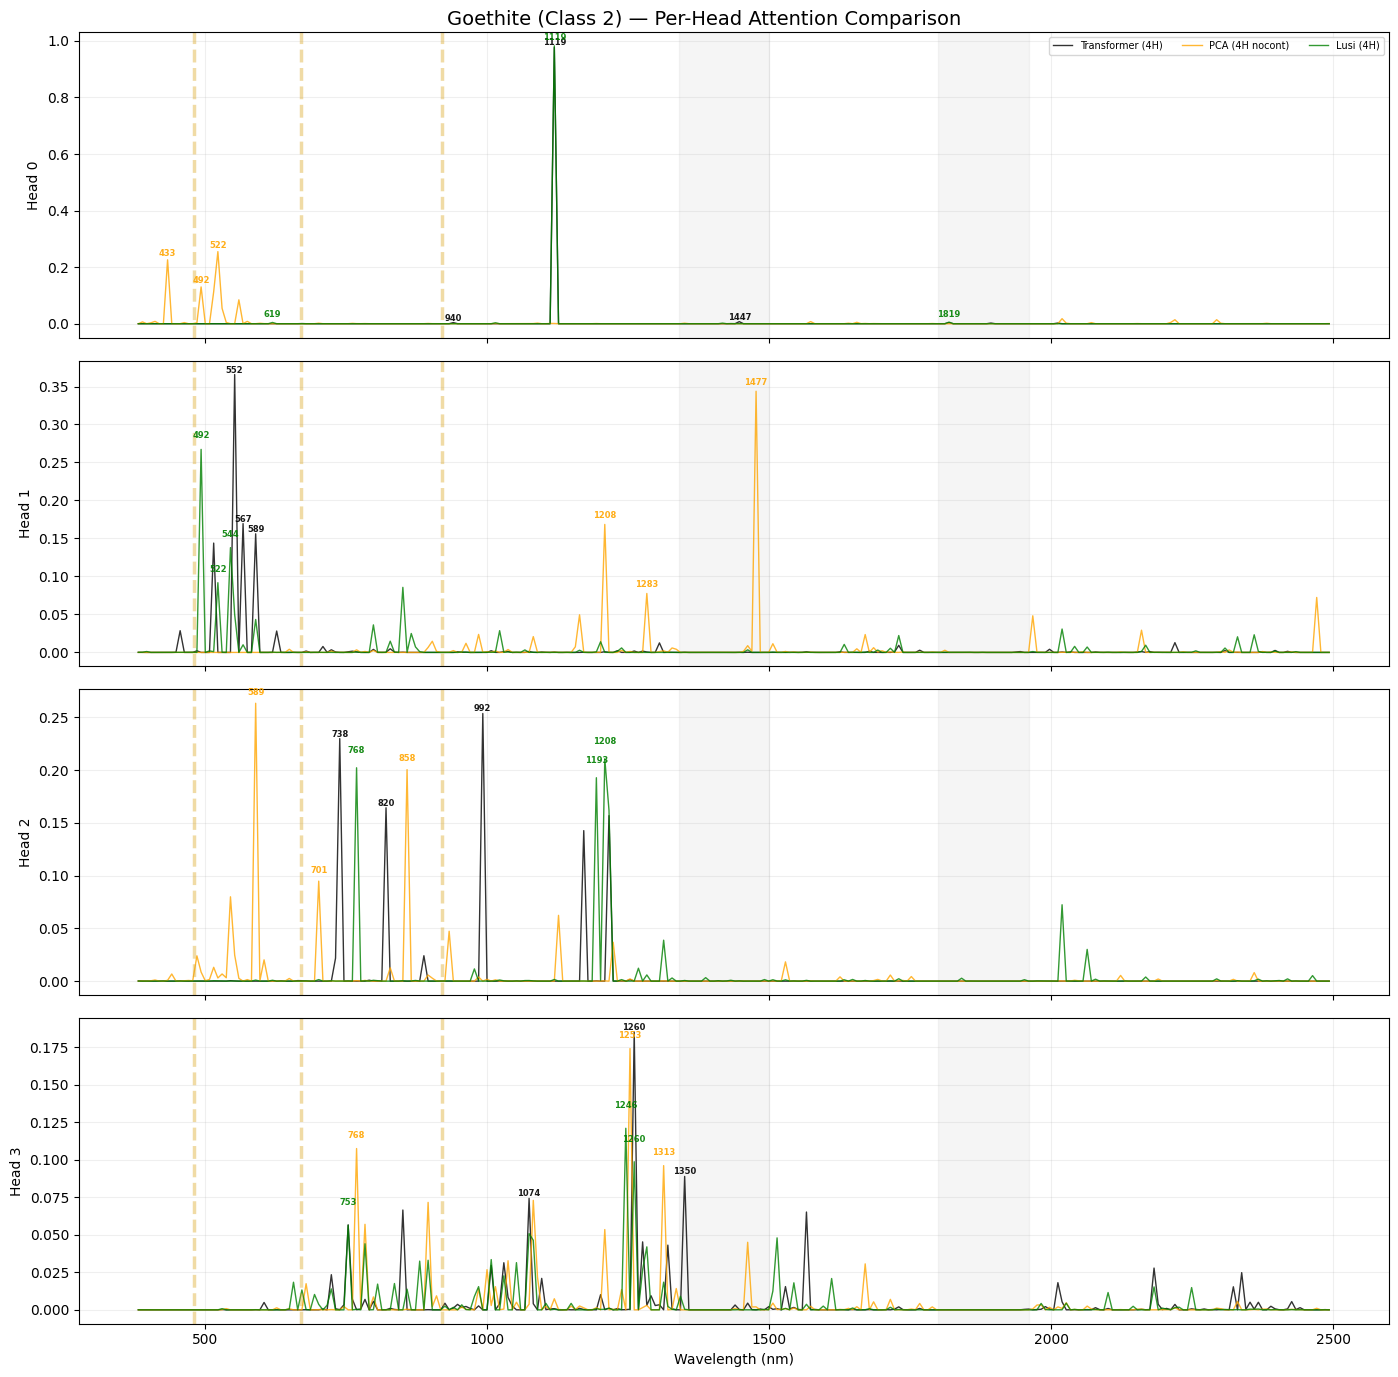

In [16]:
# ============================================================
# Compare per-head attention across 3 configurations
# Each head gets its own subplot; all 3 configs overlaid
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- PATHS ---
base = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data"
wl_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data/emit_wavelength_centers_nm.npy"

configs = {
    "Transformer (4H)": {
        "dir": f"{base}/attn_outputs_Trans4_diff",
        "color": "black",
        "n_heads": 4,
    },
    #"PCA (4H + wv mask)": {
    #    "dir": f"{base}/attn_outputs_PCA4_diffwt1_cont",
    #    "color": "steelblue",
    #    "n_heads": 4,
    #},
    "PCA (4H nocont)": {
        "dir": f"{base}/attn_outputs_PCA4_diffwt1_nocont",
       "color": "orange",
        "n_heads": 4,
    },
    "Lusi (4H)": {
        "dir": f"{base}/attn_outputs_Lusi4_diffwt1",
        "color": "green",
        "n_heads": 4,
    },
}

diagnostic_bands = {
    "Hematite":  {"bands": [530, 670, 860], "color": "firebrick"},
    "Goethite":  {"bands": [480, 670, 920], "color": "goldenrod"},
}

mineral_class_map = {
    "Hematite":  29,
    "Goethite":   2,
}

# --- LOAD ---
wl = np.load(wl_path)

# Load per-head attention for each config
attn_per_head = {}
for label, cfg in configs.items():
    attn_per_head[label] = {}
    for h in range(cfg["n_heads"]):
        try:
            attn_per_head[label][h] = np.loadtxt(
                f"{cfg['dir']}/band_attention_by_class_head{h}.csv", delimiter=","
            )
        except FileNotFoundError:
            pass

# --- PLOT: Compare heads 0-3 across configs, for each mineral ---
n_heads_to_show = 4  # show first 4 heads (all configs have at least 4)

for mineral_name, cls_idx in mineral_class_map.items():
    diag = diagnostic_bands.get(mineral_name, {})

    fig, axes = plt.subplots(n_heads_to_show, 1, figsize=(14, 3.5 * n_heads_to_show), sharex=True)
    fig.suptitle(f'{mineral_name} (Class {cls_idx}) — Per-Head Attention Comparison', fontsize=14)

    for h in range(n_heads_to_show):
        ax = axes[h]

        # Shade water vapor regions
        for lo, hi in [(1340, 1500), (1800, 1960)]:
            ax.axvspan(lo, hi, alpha=0.08, color='gray')

        # Plot each config's attention for this head
        for label, cfg in configs.items():
            if h in attn_per_head[label]:
                attn_h = attn_per_head[label][h][cls_idx]
                ax.plot(wl, attn_h, color=cfg["color"], linewidth=1.0, alpha=0.8, label=label)

        # Overlay diagnostic bands
        for band_nm in diag.get("bands", []):
            ax.axvline(band_nm, color=diag["color"], linestyle='--', linewidth=2.5, alpha=0.4)

        # Annotate top-3 peaks for each config
        y_offset_step = 0.006  # vertical offset to avoid overlapping labels
        for i_cfg, (label, cfg) in enumerate(configs.items()):
            if h in attn_per_head[label]:
                attn_h_cfg = attn_per_head[label][h][cls_idx]
                top3 = np.argsort(attn_h_cfg)[-3:]
                for idx in top3:
                    ax.annotate(f'{wl[idx]:.0f}',
                                xy=(wl[idx], attn_h_cfg[idx] + y_offset_step * i_cfg),
                                fontsize=6, ha='center', va='bottom',
                                color=cfg["color"], alpha=0.9, fontweight='bold')

        ax.set_ylabel(f'Head {h}')
        ax.grid(True, alpha=0.2)
        if h == 0:
            ax.legend(loc='upper right', fontsize=7, ncol=3)

    axes[-1].set_xlabel('Wavelength (nm)')
    plt.tight_layout()
    plt.savefig(f"{base}/perhead_comparison_{mineral_name}.png", dpi=150)
    plt.show()


In [ ]:
# ============================================================
# Spearman + Peak Coincidence across multiple configurations
# ============================================================
import numpy as np
from scipy.stats import spearmanr

# --- PATHS ---
base = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data"
wl_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data/emit_wavelength_centers_nm.npy"
wv_mask_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Spectra/group1_all/water_vapor_mask_285.npy"
ref_spectra_path = "/Users/kmccoy/Documents/USC/Research/Dissertation/Spectra/group1_all/ALL_group1_spectra_full.npy"

# --- CONFIGS (add/remove as needed) ---
configs = {
    "Transformer (4H)": {
        "dir": f"{base}/attn_outputs_Trans4_diff",
        "n_heads": 4,
    },
    "Transformer (8H)": {
        "dir": f"{base}/attn_outputs_Trans8_diff",
        "n_heads": 8,
    },
    "PCA (4H nocont)": {
        "dir": f"{base}/attn_outputs_PCA4_diffwt1_nocont",
        "n_heads": 4,
    },
    "PCA (4/8H cont)": {
        "dir": f"{base}/attn_outputs_PCA4_8_diffwt1_cont",
        "n_heads": 8,
    },
    "PCA (8H nocont)": {
        "dir": f"{base}/attn_outputs_PCA4_8_diffwt1_nocont",
        "n_heads": 8,
    },
    "LUSI (4H)": {
        "dir": f"{base}/attn_outputs_Lusi4_diffwt1",
        "n_heads": 4,
    },
    "LUSI (8H)": {
        "dir": f"{base}/attn_outputs_Lusi8_diffwt1",
        "n_heads": 8,
    },
}

# --- LOAD COMMON DATA ---
wl = np.load(wl_path)
wv_mask = np.load(wv_mask_path).astype(bool)
ref_spectra = np.load(ref_spectra_path)
ref_mean = ref_spectra.mean(axis=0)
abs_depth_good = np.clip(1.0 - ref_mean, 0, None)[wv_mask]
finite_mask = np.isfinite(abs_depth_good)

# --- DIAGNOSTIC BANDS ---
diagnostic_bands = {
    "Hematite":  {"bands": [530, 670, 860]},
    "Goethite":  {"bands": [480, 670, 920]},
}

mineral_class_map = {
    "Hematite":  29,
    "Goethite":   2,
}

tolerance_nm = 20

# --- RUN ANALYSIS FOR EACH CONFIG ---
for config_name, cfg in configs.items():
    print("\n" + "=" * 80)
    print(f"  {config_name}  ({cfg['dir'].split('/')[-1]})")
    print("=" * 80)

    # Load attention data
    try:
        attn_by_class = np.loadtxt(f"{cfg['dir']}/band_attention_by_class.csv", delimiter=",")
    except FileNotFoundError:
        print("  *** band_attention_by_class.csv not found, skipping ***")
        continue

    attn_per_head = {}
    for h in range(cfg["n_heads"]):
        try:
            attn_per_head[h] = np.loadtxt(
                f"{cfg['dir']}/band_attention_by_class_head{h}.csv", delimiter=","
            )
        except FileNotFoundError:
            pass

    # Filter to minerals with data
    plot_minerals = {}
    for name, cls_idx in mineral_class_map.items():
        if cls_idx < attn_by_class.shape[0] and attn_by_class[cls_idx].sum() > 0:
            plot_minerals[name] = cls_idx

    # --- SPEARMAN ---
    print(f"\n  {'Mineral':<16} {'Class':>5} {'Head':>5} {'Spearman r':>10} {'p-value':>10}  Notes")
    print("  " + "-" * 75)

    for mineral_name, cls_idx in plot_minerals.items():
        # Head-averaged
        attn = attn_by_class[cls_idx][wv_mask]
        both_ok = finite_mask & np.isfinite(attn) & (attn > 0)
        if both_ok.sum() > 10:
            rho, pval = spearmanr(attn[both_ok], abs_depth_good[both_ok])
            print(f"  {mineral_name:<16} {cls_idx:>5} {'avg':>5} {rho:>10.3f} {pval:>10.2e}")
        else:
            print(f"  {mineral_name:<16} {cls_idx:>5} {'avg':>5} {'N/A':>10} {'too few':>10}")

        # Per-head
        for h in range(cfg["n_heads"]):
            if h not in attn_per_head:
                continue
            attn_h = attn_per_head[h][cls_idx][wv_mask]
            both_ok = finite_mask & np.isfinite(attn_h) & (attn_h > 0)
            if both_ok.sum() > 10:
                rho, pval = spearmanr(attn_h[both_ok], abs_depth_good[both_ok])
                note = ""
                if rho > 0.3:
                    note = "<-- spectroscopically aligned"
                elif rho < -0.1:
                    note = "<-- anti-correlated"
                print(f"  {'':16} {'':>5} {'H'+str(h):>5} {rho:>10.3f} {pval:>10.2e}  {note}")

    # --- PEAK COINCIDENCE ---
    print(f"\n  Peak Coincidence (±{tolerance_nm} nm)")
    print("  " + "-" * 75)

    for mineral_name, cls_idx in plot_minerals.items():
        diag = diagnostic_bands.get(mineral_name, {})
        expected = diag.get("bands", [])
        if not expected:
            continue

        print(f"\n  {mineral_name} (Class {cls_idx}) — expected: {expected} nm")

        for h in range(cfg["n_heads"]):
            if h not in attn_per_head:
                continue
            attn_h = attn_per_head[h][cls_idx]
            top10_idx = np.argsort(attn_h)[-10:][::-1]
            top10_wl = wl[top10_idx]

            matches = []
            for peak_wl in top10_wl:
                for diag_wl in expected:
                    if abs(peak_wl - diag_wl) <= tolerance_nm:
                        matches.append((peak_wl, diag_wl))

            match_str = ", ".join([f"{p:.0f}~{d}" for p, d in matches]) if matches else "none"
            top5_str = ", ".join([f"{w:.0f}" for w in top10_wl[:5]])
            print(f"    Head {h}: top5=[{top5_str}]  matches={match_str}")

        # Head-averaged
        attn_avg = attn_by_class[cls_idx]
        top10_idx = np.argsort(attn_avg)[-10:][::-1]
        top10_wl = wl[top10_idx]
        matches = []
        for peak_wl in top10_wl:
            for diag_wl in expected:
                if abs(peak_wl - diag_wl) <= tolerance_nm:
                    matches.append((peak_wl, diag_wl))
        match_str = ", ".join([f"{p:.0f}~{d}" for p, d in matches]) if matches else "none"
        top5_str = ", ".join([f"{w:.0f}" for w in top10_wl[:5]])
        print(f"    Avg:    top5=[{top5_str}]  matches={match_str}")

print("\n" + "=" * 80)
print("  DONE")
print("=" * 80)



  Transformer (4H)  (attn_outputs_Trans4_diff)

  Mineral          Class  Head Spearman r    p-value  Notes
  ---------------------------------------------------------------------------
  Hematite            29   avg      0.222   2.27e-02
                            H0      0.051   6.14e-01  
                            H1      0.098   3.52e-01  
                            H2      0.004   9.71e-01  
                            H3      0.323   8.78e-04  <-- spectroscopically aligned
  Goethite             2   avg      0.235   1.69e-02
                            H0     -0.067   5.64e-01  
                            H1     -0.039   7.26e-01  
                            H2      0.117   5.11e-01  
                            H3      0.275   4.95e-03  

  Peak Coincidence (±20 nm)
  ---------------------------------------------------------------------------

  Hematite (Class 29) — expected: [530, 670, 860] nm
    Head 0: top5=[1119, 1447, 940, 1819, 2012]  matches=671~670
    Head 1: t